In [1]:
# use cosmidesi-main environment. Every import here is required in the written order to work, otherwise sunbird crashes

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from astropy.table import Table
import scipy.stats as stats
import pandas as pd
import pickle
import torch
import scipy

import sys

#sys.path.insert(0, '/global/u2/h/hrincon/.local/lib/python3.10/site-packages') # Add to the beginning of the path
# import version of typing extensions required for emulator packages

import typing_extensions
import lightning
import xarray

#sys.path.pop(0);

#sys.path.insert(0, '/global/cfs/cdirs/desicollab/users/epaillas/code/sunbird') # Add to the beginning of the path

from sunbird.emulators import FCN, train
from sunbird.data import ArrayDataModule
from sunbird.data.data_utils import convert_to_summary
from sunbird.data.transforms_array import LogTransform, ArcsinhTransform

#sys.path.pop(0);

from pathlib import Path

#import torch

In [2]:
# use cosmidesi-main environment. Every import here is required in the written order to work, otherwise sunbird crashes

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from astropy.table import Table
import scipy.stats as stats
import pandas as pd
import pickle
import torch
import scipy

import sys

sys.path.insert(0, '/global/u2/h/hrincon/.local/lib/python3.10/site-packages') # Add to the beginning of the path
# import version of typing extensions required for emulator packages

import typing_extensions
import lightning
import xarray

sys.path.pop(0);

sys.path.insert(0, '/global/homes/h/hrincon/code/sunbird') # Add to the beginning of the path

from pathlib import Path
from sunbird.emulators import FCN, train
from sunbird.data import ArrayDataModule
from sunbird.data.data_utils import convert_to_summary
from sunbird.data.transforms_array import LogTransform, ArcsinhTransform
#import torch

In [2]:
torch.set_float32_matmul_precision('high')


In [3]:
sys.path.insert(1, '/global/homes/h/hrincon/python_tools')
import Util as util

In [4]:
import os


In [5]:
cosmo_list = ["c000", "c001", "c002", "c003", "c004", "c013",
              "c100", "c101", "c102", "c103", "c104", "c105", "c106", "c107", "c108", "c109", 
              "c110", "c111", "c112", "c113", "c114", "c115", "c116", "c117", "c118", "c119", 
              "c120", "c121", "c122", "c123", "c124", "c125", "c126", 
              "c130", "c131", "c132", "c133", "c134", "c135", "c136", "c137", "c138", "c139", 
              "c140", "c141", "c142", "c143", "c144", "c145", "c146", "c147", "c148", "c149", 
              "c150", "c151", "c152", "c153", "c154", "c155", "c156", "c157", "c158", "c159",
              "c160", "c161", "c162", "c163", "c164", "c165", "c166", "c167", "c168", "c169",
              "c170", "c171", "c172", "c173", "c174", "c175", "c176", "c177", "c178", "c179",
              "c180", "c181"
             ]

cosmologies_file = 'abacus_cosmologies.csv'
cosmologies = pd.read_csv(cosmologies_file)

point_names = [
    'omega_b','omega_cdm', 'n_s', 'alpha_s', 'N_ur', 'w0_fld', 'wa_fld', 'sigma8_cb',
    'logM_cut', 'logM_1', 'sigma', 'alpha', 'kappa', 'alpha_c', 'alpha_s2', 's', 'A_cen', 'A_sat', 'B_cen', 'B_sat'
]



In [75]:
nathan_hod_params = np.load("/pscratch/sd/n/ntbfin/emulator/hods/hod_params.npy", allow_pickle=True)[()] 

In [87]:
from astropy.io import fits
def cosmo_to_params (cosmo):
    cosmo_row = cosmologies.loc[cosmologies['root'] == "abacus_"+cosmo.replace('c','cosm')]
    row = cosmo_row.loc[:, ['omega_b', 'omega_cdm', 'n_s',  'alpha_s', 'N_ur', 'w0_fld', 'wa_fld', 'sigma8_cb']]
    return row.to_numpy().astype(np.float64)[0]

def hod_to_params (cosmo, hod):
    #hod_map = pd.read_csv(f'/pscratch/sd/e/epaillas/emc/hod_params/yuan23/cosmo_split/hod_params_yuan23_{cosmo}.csv')
    #return hod_map.iloc[hod].to_numpy()
    hod_map = [nathan_hod_params[cosmo]['logM_cut'][hod], 
               nathan_hod_params[cosmo]['logM_1'][hod], 
               nathan_hod_params[cosmo]['sigma'][hod], 
               nathan_hod_params[cosmo]['alpha'][hod], 
               nathan_hod_params[cosmo]['kappa'][hod], 
               nathan_hod_params[cosmo]['alpha_c'][hod],
               nathan_hod_params[cosmo]['alpha_s'][hod],
               nathan_hod_params[cosmo]['s'][hod],
               nathan_hod_params[cosmo]['A_cen'][hod],
               nathan_hod_params[cosmo]['A_sat'][hod],
               nathan_hod_params[cosmo]['B_cen'][hod],
               nathan_hod_params[cosmo]['B_sat'][hod]
              ]
    return np.array(hod_map)

def cosmo_hod_to_params (cosmo, hod):
    cosmo_hod_params = np.concatenate([cosmo_to_params (cosmo), hod_to_params (cosmo, hod)])
    return cosmo_hod_params

def load_vsf():
    points = []
    values = []
    phases = []
    bins = np.linspace(0,100,1001)
    
    
    #for cosmo in cosmo_list:
    for cosmo in cosmo_list:
        void_dir = f'/pscratch/sd/h/hrincon/desigroup/VoidFinder/ACM_AP/Cubic/LRG/{cosmo}/z0.500/'
        ap_path = f'/pscratch/sd/n/ntbfin/emulator/hods/z0.5/yuan23_prior/{cosmo}_ph000/seed0/'
        for void_file in os.listdir(void_dir):
            hod_idx = int(void_file[10:13])
            hod_file = os.path.join(ap_path, f'hod{void_file[10:13]}.fits')
            hod_header = fits.open(hod_file)
            params = cosmo_hod_to_params(cosmo, hod_idx)
            points.append(params)
            voids = Table.read(void_dir+void_file, hdu=1)
            counts, _ = np.histogram(voids['radius'], bins = bins)
            values.append( counts)
    
    print('Alt cosmologies loaded')
    void_dir = '/pscratch/sd/h/hrincon/desigroup/VoidFinder/ACM_AP_phase/Cubic/LRG/c000/covariance/z0.500/'
    for void_file in os.listdir(void_dir):
        voids = Table.read(void_dir+void_file, hdu=1)
        counts, _ = np.histogram(voids['radius'], bins = bins)
        phases.append(counts)

    print('Cov loaded')

    return np.vstack(points), np.vstack(values), np.vstack(phases), bins #np.vstack(phases)*64 scales the VSF to the Abacus base sim box size
    
vsf_points, vsf_values, vsf_phases, vsf_bins = load_vsf()

Alt cosmologies loaded
Cov loaded


In [89]:
util.dump((vsf_points, vsf_values, vsf_phases, vsf_bins), 'ACM_AP_VSF')

In [90]:
vsf_points, vsf_values, vsf_phases, vsf_bins = util.load('ACM_AP_VSF')

In [91]:
vsf_phases_base_volume = np.sum(vsf_phases[:1728].reshape((64,27,1000)), axis = 0)

In [92]:
vsf_values = np.sum(vsf_values.reshape((vsf_values.shape[0], 100, 10)), axis=2)
vsf_phases = np.sum(vsf_phases.reshape((vsf_phases.shape[0], 100, 10)), axis=2)
vsf_phases_base_volume=np.sum(vsf_phases_base_volume.reshape((vsf_phases_base_volume.shape[0], 100, 10)), axis=2)
vsf_bins = np.concat([vsf_bins[:-1].reshape(100, 10)[:,0], [vsf_bins[-1]]])

# nonzero values
vsf_values=vsf_values[:,10:40]
vsf_phases=vsf_phases[:,10:40]
vsf_phases_base_volume=vsf_phases_base_volume[:,10:40]
vsf_bins=vsf_bins[10:41]

vsf_bin_centers = (vsf_bins[:-1] + vsf_bins[1:])/2

In [7]:
def load_statistic(stat_name):
    points = []
    values = []
    file_IDs = []
    
    #for cosmo in cosmo_list:
    for cosmo in cosmo_list:
        value = util.load(f'ACM_AP_{stat_name}_values_{cosmo}')
        point = util.load(f'ACM_AP_{stat_name}_points_{cosmo}')
        file_ID = util.load(f'ACM_AP_{stat_name}_file_IDs_{cosmo}')
        #print(value.shape, cosmo)
        values.append(value)
        points.append(point)
        file_IDs.append(file_ID)
    
    points = np.vstack(points)
    values=np.vstack(values)
    file_IDs=np.concatenate(file_IDs)

    return points, values, file_IDs

def load_alternate_realizations(stat_name):
    
    phases = []
    files = [file for file in os.listdir('/global/homes/h/hrincon/ACM/vast_tools_storage/cov_AP/') if file.startswith(stat_name)]

    for file in files:
        phase = util.load(f'cov_AP/{file}')
        if len(phase.shape) == 4:
            phases.append(phase)

    phases=np.vstack(phases)
    
    return phases

def load_training_data(stat_name):

    points, values, file_IDs = load_statistic(stat_name)

    phases = load_alternate_realizations(stat_name)

    return points, values, file_IDs, phases
    

In [8]:
#vvac_points, vvac_values, vvac_files, vvac_phases = load_training_data('vvac')
vgcc_points, vgcc_values, vgcc_files, vgcc_phases = load_training_data('vgcc')

In [9]:
#vvac_bins = np.array(sedges)
#vvac_bin_centers = vvac_bins[:-1] + np.diff(vvac_bins)/2
sedges = np.arange(1, 150, 1)
vgcc_bins = np.array(sedges)
vgcc_bin_centers = vgcc_bins[:-1] + np.diff(vgcc_bins)/2

In [69]:
# cut to where there are a good # of covariance mocks
"""vvac_select_phases = ~np.isnan(np.prod(np.prod(vvac_phases[:,:,22:100], axis=2), axis=1))
vvac_phases = vvac_phases[vvac_select_phases,:,22:100]
vvac_values = vvac_values[:,:,22:100]
vvac_bin_centers=vvac_bin_centers[22:100]""";

In [70]:
# cut to where there are a good # of covariance mocks
# latest version has no nan values so comment this all out
#vgcc_select_phases = ~np.isnan(np.prod(np.prod(np.prod(vgcc_phases[...,2:], axis=3), axis=2), axis=1))
#vgcc_phases = vgcc_phases[vgcc_select_phases,:,2:]
#vgcc_values = vgcc_values[:,:,2:]
#vgcc_bin_centers=vgcc_bin_centers[2:]

In [12]:
#from acm.utils.xarray_data import dataset_to_dict

In [163]:
# compress data
# TODO: remove the vvac block once vvac is working again
"""for bins, points, values, phases, statname in zip ([vvac_bin_centers, vgcc_bin_centers],
                                            [vvac_points, vgcc_points],
                                            [vvac_values, vgcc_values],
                                            [vvac_phases, vgcc_phases],
                                            ['vf_void_autocorrelation', 'vf_void_galaxy_cross_correlation']
                                           ):"""

for bins, points, values, phases, statname in zip ([vgcc_bin_centers],
                                            [vgcc_points],
                                            [vgcc_values],
                                            [vgcc_phases],
                                            ['vf_void_galaxy_cross_correlation']
                                           ):

    # todo: replace sigma8_cb wiht true sigma_8 values
    point_names_compressed = [
    'omega_b','omega_cdm', 'n_s', 'nrun', 'N_ur', 'w0_fld', 'wa_fld', 'sigma8_m',
    'logM_cut', 'logM_1', 'sigma', 'alpha', 'kappa', 'alpha_c', 'alpha_s', 's', 'A_cen', 'A_sat', 'B_cen', 'B_sat'
    ]
    
    prior_min = np.min(points,axis=0)
    prior_max = np.max(points,axis=0)
    #x = (points - prior_min)/(prior_max-prior_min)
    x=points

    y = values

    y = xarray.DataArray(
            data = y,
            coords = {
                'cosmo_hod_idx': list(range(y.shape[0])),
                'r_bins' : [0,1,2,3,4],
                'multipoles': [0,2,4],
                's': bins,
            },
            attrs = {
                'sample': ['cosmo_hod_idx'],
                'features': ['r_bins', 'multipoles', 's'],
            },
            name = 'y',
    )

    x = xarray.DataArray(
            x,
            coords = {
                'cosmo_hod_idx': list(range(x.shape[0])),
                'parameters': point_names_compressed,
            },
            attrs= {
                'sample': ['cosmo_hod_idx'],
                'features': ['parameters'],
            },
            name = 'x',
        )
    
    cout = xarray.Dataset(
            data_vars = {
                'x': x,
                'y': y,
            },
        )

    save_fn = f'./compressed/data/{statname}_rbin'
    np.save(save_fn, dataset_to_dict(cout))

    c = phases

    c = xarray.DataArray(
            data = c,
            coords = {
                "phase_idx": list(range(c.shape[0])),
                'r_bins' : [0,1,2,3,4],
                "multipoles": [0,2,4],
                "s": bins,
            },
            attrs = {
                "sample": ["phase_idx"],
                "features": ["r_bins", "multipoles", "s"],
            },
            name = "covariance_y",
        )

    cov_y = xarray.Dataset(
            data_vars = {
                'covariance_y': c,
            },
        )
    
    save_fn = f'./compressed/cov/{statname}_rbin'
    np.save(save_fn, dataset_to_dict(cov_y))
        

In [43]:
# flatten data vector
#vvac_values = np.squeeze(vvac_values.reshape(vvac_values.shape[0],1,-1))
#vvac_phases = np.squeeze(vvac_phases.reshape(vvac_phases.shape[0],1,-1))
#vvac_bin_centers=np.arange(2*len(vvac_bin_centers))

In [15]:
# flatten data vector

vgcc_values = vgcc_values[:,:,1:,...] # idea for debugging
vgcc_phases = vgcc_phases[:,:,1:,...]

bin_mult = vgcc_values.shape[1]*vgcc_values.shape[2] # num radial bins times num multipoles
vgcc_values = np.squeeze(vgcc_values.reshape(vgcc_values.shape[0],1,-1))
vgcc_phases = np.squeeze(vgcc_phases.reshape(vgcc_phases.shape[0],1,-1))
vgcc_bin_centers=np.arange(bin_mult*len(vgcc_bin_centers))

In [24]:
# compress data
for bins, points, values, phases, statname in zip ([vvac_bin_centers, vgcc_bin_centers],
                                            [vvac_points, vgcc_points],
                                            [vvac_values, vgcc_values],
                                            [vvac_phases, vgcc_phases],
                                            ['vf_void_autocorrelation', 'vf_void_galaxy_cross_correlation']
                                           ):

    # todo: replace sigma8_cb wiht true sigma_8 values
    point_names_compressed = [
    'omega_b','omega_cdm', 'n_s', 'nrun', 'N_ur', 'w0_fld', 'wa_fld', 'sigma8_m',
    'logM_cut', 'logM_1', 'sigma', 'alpha', 'kappa', 'alpha_c', 'alpha_s', 's', 'A_cen', 'A_sat', 'B_cen', 'B_sat'
    ]
    
    #prior_min = np.min(points,axis=0)
    #prior_max = np.max(points,axis=0)
    #x = (points - prior_min)/(prior_max-prior_min)
    x = points

    y = values

    y = xarray.DataArray(
            data = y,
            coords = {
                'cosmo_hod_idx': list(range(y.shape[0])),
                's': bins,
            },
            attrs = {
                'sample': ['cosmo_hod_idx'],
                'features': ['s'],
            },
            name = 'y',
    )

    x = xarray.DataArray(
            x,
            coords = {
                'cosmo_hod_idx': list(range(x.shape[0])),
                'parameters': point_names_compressed,
            },
            attrs= {
                'sample': ['cosmo_hod_idx'],
                'features': ['parameters'],
            },
            name = 'x',
        )
    
    cout = xarray.Dataset(
            data_vars = {
                'x': x,
                'y': y,
            },
        )

    save_fn = f'./compressed/data/{statname}'
    np.save(save_fn, dataset_to_dict(cout))

    c = phases

    c = xarray.DataArray(
            data = c,
            coords = {
                "phase_idx": list(range(c.shape[0])),
                "s": bins,
            },
            attrs = {
                "sample": ["phase_idx"],
                "features": ["s"],
            },
            name = "covariance_y",
        )

    cov_y = xarray.Dataset(
            data_vars = {
                'covariance_y': c,
            },
        )
    
    save_fn = f'./compressed/cov/{statname}'
    np.save(save_fn, dataset_to_dict(cov_y))

    

    
        

In [8]:
from scipy.special import factorial, loggamma


def logposterior(theta_vsf, data, emulator, prior, bin_centers, bin_min = -np.inf, bin_max = np.inf):
    #theta must be a list or array, not a tuple
    theta_vsf = np.array(theta_vsf)
    
    lp = logprior(theta_vsf, prior) # get the prior
        
    if not np.isfinite(lp):
        return -np.inf

    return lp + loglikelihood(theta_vsf, data, emulator, bin_centers, bin_min, bin_max)


def loglikelihood(theta_vsf, data, emulator, bin_centers, bin_min, bin_max): #

 
    vsf = theta_vsf
    #vsf[vsf<=1] = 1 # so-so way of getting around error, better to adjust the bin limits

    #adjust bin limits
    select = (bin_centers > bin_min) * (bin_centers < bin_max) 

    data = data[select]
    vsf = vsf[select]

    #the interpolated volume for theta
    # log poisson likelihood
    # N(theta) = number density * fiducial survey volume * volume correction for model
    # Sum_{r,z} ( N(data) * log (N(theta)) - N(theta) - factorial(N(data)) )
    rtrn = np.sum((data*np.log(vsf)) - vsf - loggamma(data+1))
    
    if np.isnan(rtrn):
        return -np.inf
    else:
        return rtrn

def logprior(theta, prior): #priors,):
    
    """lp=0.
    
    for param, prior in zip(theta, priors):
        #uniform prior
        lp += 0. if prior[0] <= param <= prior[1] else -np.inf"""
    lp = 0 #if prior(theta) else -np.inf
   
    return lp


In [28]:
#vsf_phases_base_volume[1:,vsf_bin_centers<35]

In [134]:
point_names

['omega_b',
 'omega_cdm',
 'n_s',
 'alpha_s',
 'N_ur',
 'w0_fld',
 'wa_fld',
 'sigma8_cb',
 'logM_cut',
 'logM_1',
 'sigma',
 'alpha',
 'kappa',
 'alpha_c',
 'alpha_s2',
 's',
 'A_cen',
 'A_sat',
 'B_cen',
 'B_sat']

In [369]:
from scipy.optimize import fsolve
def in_ellipsoid(point, prior_min, prior_max):
    
            
    omegab, omega_c, ns, alpha_s, Nur, w0, wa, sigma8cb = point[:8]
    prior_select=np.arange(len(point))

    def prior_equations(vector):
        v0, v1, v2, v3, v4, v5, v6, v7 = vector
        
        root_omegab = 0.02237 * np.exp(0.10 * v3) - omegab
        root_omega_c = 0.1200 * np.exp(0.100 * v1 + 0.165 * v6) - omega_c
        root_ns = 0.9649 + 0.06 * v2 + 0.05 * v6 - ns
        root_alpha_s = 0.05 * v7 - alpha_s
        root_Nur = 2.0328 + 1.2 * v6 - Nur
        root_w0 = -1.0 + 0.3 * v4 - 0.2 * v5 - w0
        root_wa = 0.8 * v5 - wa
        root_sigma8cb = 0.811355 * (1 + 0.12 * v0 - 0.125 * v4) - sigma8cb
                
        return [root_omegab, root_omega_c, root_ns, root_alpha_s, root_Nur, root_w0, root_wa, root_sigma8cb]
    
    vector_guess = np.ones(8)
    #vector_guess = np.ones(2)

    # Solve the system
    unit_points = fsolve(prior_equations, vector_guess)
    # check that cosmology is in ellispod
    emulator_magnitude = np.linalg.norm(unit_points)
    # check that cosmology+hod is in bounding cube
    unit_cube_transform = (point - prior_min[prior_select])/(prior_max[prior_select]-prior_min[prior_select])

    in_cube = (np.min(unit_cube_transform)>=0) * (np.max(unit_cube_transform)<=1)

    in_bounds = (emulator_magnitude <= 1) * in_cube
    
    return in_bounds, emulator_magnitude



def get_inisamples(Nens, prior_min, prior_max, model='lcdm'):
     
    inisamples=[]
    point_displacements =[]
    print('Creating inital samples')
    while len(inisamples) < Nens:
        guess = [np.random.uniform(low, high, 1)[0].item() for low, high in zip(prior_min, prior_max)]
        if model == 'lcdm':
            guess[3]=0.
            guess[4]=2.0328
            guess[5]=-1.
            guess[6]=0.
        elif model == 'wcdm':
            guess[3]=0.
            guess[4]=2.0328
            guess[6]=0.
        elif model == 'w0wacdm':
            guess[3]=0.
            guess[4]=2.0328
            guess[6]=0.
        elif model == 'exp':
            '''guess[0]=0.02237
            guess[1] = 0.12
            guess[2] = 0.9649'''
            guess[3]=0.
            guess[4]=2.0328
            guess[5]=-1.
            guess[6]=0.
            #guess[7] = 0.811355
            guess[8] = 12.53641
            guess[9] =  13.97509
            guess[10] =  -1.07039
            guess[11] =  0.96479
            guess[12] =  0.15045
            guess[13] =  0.35632
            guess[14] =  0.75057
            guess[15] =  0.59993
            guess[16] =  -0.78284
            guess[17] =  -0.5698
            guess[18] = -0.27336
            guess[19] =  -0.23689
        else:
            raise ValueError(f'invalid model {model}')

        """guess[8] = 12.53641
        guess[9] =  13.97509
        guess[10] =  -1.07039
        guess[11] =  0.96479
        guess[12] =  0.15045
        guess[13] =  0.35632
        guess[14] =  0.75057
        guess[15] =  0.59993
        guess[16] =  -0.78284
        guess[17] =  -0.5698
        guess[18] = -0.27336
        guess[19] =  -0.23689"""
            
        is_in_bounds, point_displacement = in_ellipsoid(guess, prior_min, prior_max)
        if is_in_bounds:
            inisamples.append(guess)
            point_displacements.append(point_displacement)
            
    inisamples=np.array(inisamples)
    point_displacements=np.array(point_displacements)
    return inisamples, point_displacements


def get_prediction(model, points, prior_min, prior_max):

    points = (points - prior_min)/(prior_max-prior_min)

    with torch.no_grad():
        prediction = model.get_prediction(torch.Tensor(points))
            
        prediction = prediction.numpy()
        
    return prediction


In [312]:
from scipy.stats import poisson, chisquare

def get_llhs_pvals(values, test_values):
    m1 = vsf_bin_centers[np.all(values>0, axis=0)][-1].item()
    m2 = vsf_bin_centers[np.all(test_values>0, axis=0)][-1].item()
    max_bin=np.min([m1, m2])
    print('max bin:',max_bin)
    expected_vsf = np.mean(values[:,vsf_bin_centers<=max_bin], axis=0)
    log_llhs = [np.sum(poisson.logpmf(data, expected_vsf)).item() for data in values[:,vsf_bin_centers<=max_bin]]
    log_llhs=np.array(log_llhs)

    test_log_llhs = [np.sum(poisson.logpmf(data, expected_vsf)).item() for data in test_values[:,vsf_bin_centers<=max_bin]]
    test_log_llhs=np.array(test_log_llhs)

    pvals = [np.sum(log_llhs < np.sum(poisson.logpmf(test_values[mock_index][vsf_bin_centers<=max_bin], expected_vsf)))/len(log_llhs) for mock_index in range(len(test_values))]

    return log_llhs, test_log_llhs, pvals

In [286]:
def plot_llhs(log_llhs, pv_bin_count = 100, label=None, density=False):
    
    plt.hist(log_llhs, bins=pv_bin_count, histtype='step', label=label, density=density); plt.xlabel('log likelihood'); plt.ylabel('count'); plt.title('Log likelihood distribution for lambdaCDM base mocks');


In [370]:
# w0waCDM precentage of p values below 0.05 (fixed HOD)
len(np.array(w0wacdm_uniform_pvals)[np.array(w0wacdm_uniform_pvals)<.05])/len(w0wacdm_uniform_pvals)

0.3969

In [368]:
# wCDM precentage of p values below 0.05 (fixed HOD)
len(np.array(wcdm_uniform_pvals)[np.array(wcdm_uniform_pvals)<.05])/len(wcdm_uniform_pvals)

0.387

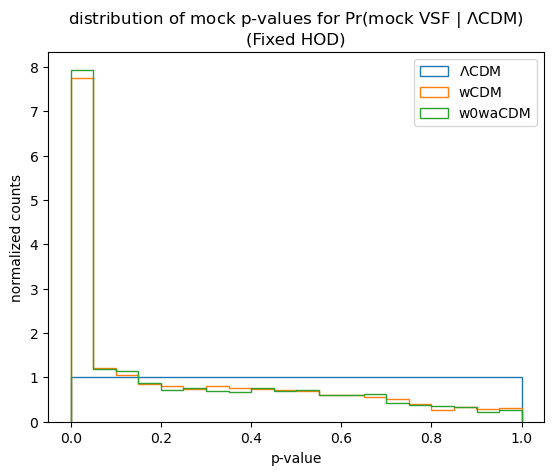

In [360]:
plt.hist(lcdm_uniform_pvals, histtype='step', density=True, label='$\\Lambda$CDM',bins=20)
plt.hist(wcdm_uniform_pvals, histtype='step', density=True, label='wCDM',bins=20)
plt.hist(w0wacdm_uniform_pvals, histtype='step', density=True, label='w0waCDM',bins=20)
plt.legend();plt.xlabel('p-value');plt.ylabel('normalized counts');plt.title('distribution of mock p-values for Pr(mock VSF | $\\Lambda$CDM)\n(Fixed HOD)')
plt.show()

In [317]:
exp_uniform_sampling, exp_uniform_disp = get_inisamples(10000, np.min(vsf_points,axis=0), np.max(vsf_points,axis=0), model='exp')

Creating inital samples


In [318]:
exp_uniform_predictions = get_prediction(vsf_model, exp_uniform_sampling, np.min(vsf_points,axis=0), np.max(vsf_points,axis=0))
exp_uniform_predictions = exp_uniform_predictions.astype(int)

In [319]:
_, exp_uniform_llhs, exp_uniform_pvals = get_llhs_pvals(exp_uniform_predictions, exp_uniform_predictions)

max bin: 33.5


In [371]:
lcdm_uniform_sampling, lcdm_uniform_disp = get_inisamples(10000, np.min(vsf_points,axis=0), np.max(vsf_points,axis=0), model='lcdm')

Creating inital samples


In [372]:
lcdm_uniform_predictions = get_prediction(vsf_model, lcdm_uniform_sampling, np.min(vsf_points,axis=0), np.max(vsf_points,axis=0))
lcdm_uniform_predictions = lcdm_uniform_predictions.astype(int)

In [373]:
wcdm_uniform_sampling, wcdm_uniform_disp = get_inisamples(10000, np.min(vsf_points,axis=0), np.max(vsf_points,axis=0), model='wcdm')

Creating inital samples


In [374]:
wcdm_uniform_predictions = get_prediction(vsf_model, wcdm_uniform_sampling, np.min(vsf_points,axis=0), np.max(vsf_points,axis=0))
wcdm_uniform_predictions = wcdm_uniform_predictions.astype(int)

In [375]:
_, wcdm_uniform_llhs, wcdm_uniform_pvals = get_llhs_pvals(lcdm_uniform_predictions, wcdm_uniform_predictions)

max bin: 27.5


In [376]:
w0wacdm_uniform_sampling, w0wacdm_uniform_disp = get_inisamples(10000, np.min(vsf_points,axis=0), np.max(vsf_points,axis=0), model='w0wacdm')

Creating inital samples


In [377]:
w0wacdm_uniform_predictions = get_prediction(vsf_model, w0wacdm_uniform_sampling, np.min(vsf_points,axis=0), np.max(vsf_points,axis=0))
w0wacdm_uniform_predictions = w0wacdm_uniform_predictions.astype(int)

In [378]:
_, w0wacdm_uniform_llhs, w0wacdm_uniform_pvals = get_llhs_pvals(lcdm_uniform_predictions, w0wacdm_uniform_predictions)

max bin: 27.5


In [383]:
np.min(w0wacdm_uniform_sampling,axis=0), np.max(w0wacdm_uniform_sampling,axis=0), np.min(w0wacdm_uniform_sampling,axis=0) - np.max(w0wacdm_uniform_sampling,axis=0)

(array([ 2.07315073e-02,  1.09036313e-01,  9.07174148e-01,  0.00000000e+00,
         2.03280000e+00, -1.27053248e+00,  0.00000000e+00,  6.81173548e-01,
         1.25001626e+01,  1.36001639e+01, -2.98977670e+00,  3.00222535e-01,
         6.87420080e-05,  7.70066222e-05,  5.80109106e-01, -9.79925548e-01,
        -9.89703841e-01, -9.99429609e-01, -6.69846889e-01, -9.69368361e-01]),
 array([ 0.02427951,  0.13186381,  1.02116551,  0.        ,  2.0328    ,
        -0.70850081,  0.        ,  0.94148197, 13.69949299, 15.0999568 ,
         0.95892266,  1.47968947,  0.98986382,  0.60983861,  1.48985481,
         0.99968757,  0.92978155,  0.99940228,  0.19971598,  0.9892044 ]),
 array([-3.54800151e-03, -2.28274974e-02, -1.13991363e-01,  0.00000000e+00,
         0.00000000e+00, -5.62031673e-01,  0.00000000e+00, -2.60308420e-01,
        -1.19933036e+00, -1.49979289e+00, -3.94869936e+00, -1.17946693e+00,
        -9.89795082e-01, -6.09761601e-01, -9.09745703e-01, -1.97961312e+00,
        -1.91948539e

In [386]:
for pn, mi, ma in zip(point_names, np.min(w0wacdm_uniform_sampling,axis=0), np.max(w0wacdm_uniform_sampling,axis=0)):
    print(pn, f'{mi:.3g}, {ma:.3g}, {ma-mi:.3g}')

omega_b 0.0207, 0.0243, 0.00355
omega_cdm 0.109, 0.132, 0.0228
n_s 0.907, 1.02, 0.114
alpha_s 0, 0, 0
N_ur 2.03, 2.03, 0
w0_fld -1.27, -0.709, 0.562
wa_fld 0, 0, 0
sigma8_cb 0.681, 0.941, 0.26
logM_cut 12.5, 13.7, 1.2
logM_1 13.6, 15.1, 1.5
sigma -2.99, 0.959, 3.95
alpha 0.3, 1.48, 1.18
kappa 6.87e-05, 0.99, 0.99
alpha_c 7.7e-05, 0.61, 0.61
alpha_s2 0.58, 1.49, 0.91
s -0.98, 1, 1.98
A_cen -0.99, 0.93, 1.92
A_sat -0.999, 0.999, 2
B_cen -0.67, 0.2, 0.87
B_sat -0.969, 0.989, 1.96


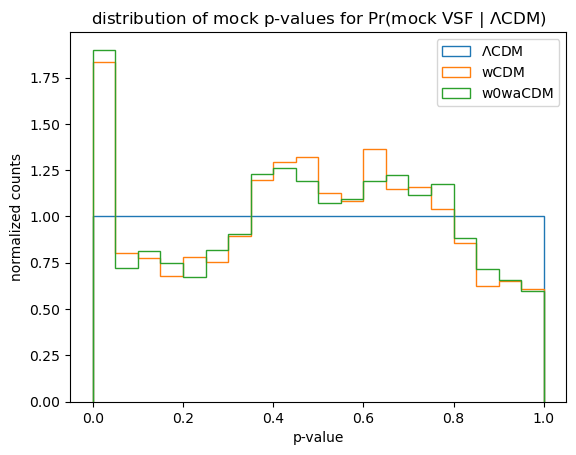

In [350]:
plt.hist(lcdm_uniform_pvals, histtype='step', density=True, label='$\\Lambda$CDM',bins=20)
plt.hist(wcdm_uniform_pvals, histtype='step', density=True, label='wCDM',bins=20)
plt.hist(w0wacdm_uniform_pvals, histtype='step', density=True, label='w0waCDM',bins=20)
plt.legend();plt.xlabel('p-value');plt.ylabel('normalized counts');plt.title('distribution of mock p-values for Pr(mock VSF | $\\Lambda$CDM)')
plt.show()

In [379]:
# w0waCDM precentage of p values below 0.05 (variable HOD)
len(np.array(w0wacdm_uniform_pvals)[np.array(w0wacdm_uniform_pvals)<.05])/len(w0wacdm_uniform_pvals)


0.0956

In [380]:
# wCDM precentage of p values below 0.05 (variable HOD)
len(np.array(wcdm_uniform_pvals)[np.array(wcdm_uniform_pvals)<.05])/len(wcdm_uniform_pvals)

0.0904

In [141]:
select_lambdaCDM = (vsf_points[:,3]==0)*(vsf_points[:,4]==2.0328)*(vsf_points[:,5]==-1.)*(vsf_points[:,6]==0.)

In [148]:
select_wCDM = (vsf_points[:,3]==0)*(vsf_points[:,4]==2.0328)*(vsf_points[:,5]!=-1.)*(vsf_points[:,6]==0.)

In [152]:
select_w0waCDM = (vsf_points[:,3]==0)*(vsf_points[:,4]==2.0328)*(vsf_points[:,6]!=0.)

In [146]:
max_bin=vsf_bin_centers[np.all(vsf_values>0, axis=0)][-1].item()
expected_vsf = np.mean(vsf_values[select_lambdaCDM][:,vsf_bin_centers<=max_bin], axis=0)
log_llhs = [np.sum(poisson.logpmf(data, expected_vsf)).item() for data in vsf_values[:,vsf_bin_centers<=max_bin]]
log_llhs=np.array(log_llhs)

In [183]:
vsf_values[0][vsf_bin_centers<=max_bin]

array([60454, 54296, 48204, 42414, 36680, 31298, 26666, 21627, 17885,
       14044, 10756,  8576,  5942,  4391,  2941,  1828,  1083])

In [189]:
lambdaCDM_pvals = [np.sum(log_llhs < np.sum(poisson.logpmf(vsf_values[cov_mock_index][vsf_bin_centers<=max_bin], expected_vsf)))/len(log_llhs) for cov_mock_index in np.where(select_lambdaCDM)[0]]
wCDM_pvals = [np.sum(log_llhs < np.sum(poisson.logpmf(vsf_values[cov_mock_index][vsf_bin_centers<=max_bin], expected_vsf)))/len(log_llhs) for cov_mock_index in np.where(select_wCDM)[0]]
w0waCDM_pvals = [np.sum(log_llhs < np.sum(poisson.logpmf(vsf_values[cov_mock_index][vsf_bin_centers<=max_bin], expected_vsf)))/len(log_llhs) for cov_mock_index in np.where(select_w0waCDM)[0]]


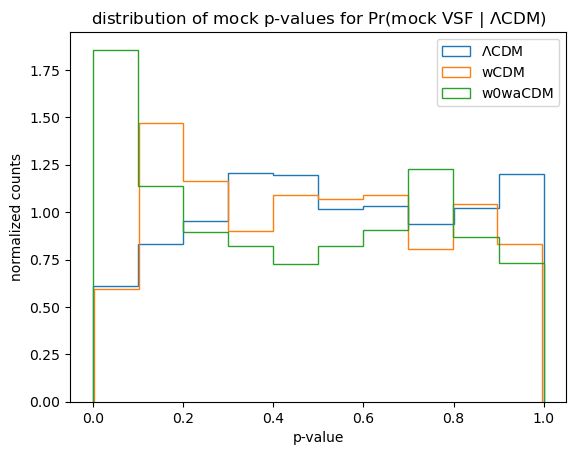

In [204]:
plt.hist(lambdaCDM_pvals, histtype='step', density=True, label='$\\Lambda$CDM',bins=10)
plt.hist(wCDM_pvals, histtype='step', density=True, label='wCDM',bins=10)
plt.hist(w0waCDM_pvals, histtype='step', density=True, label='w0waCDM',bins=10)
plt.legend();plt.xlabel('p-value');plt.ylabel('normalized counts');plt.title('distribution of mock p-values for Pr(mock VSF | $\\Lambda$CDM)')
plt.show()

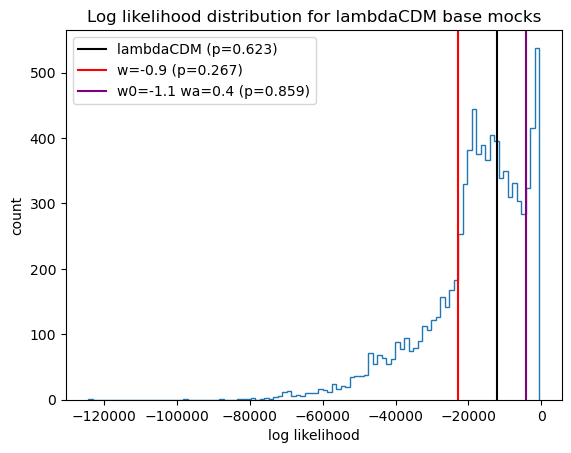

In [180]:
pv_bin_count = 100
plt.hist(log_llhs, bins=pv_bin_count, histtype='step'); plt.xlabel('log likelihood'); plt.ylabel('count'); plt.title('Log likelihood distribution for lambdaCDM base mocks');

cov_mock_index = 100
cov_mock_index = np.where(select_lambdaCDM)[0][cov_mock_index]
pv_threshold = log_llhs < np.sum(poisson.logpmf(vsf_values[cov_mock_index][vsf_bin_centers<=max_bin], expected_vsf)).item()
p_value = np.sum(pv_threshold)/len(log_llhs)

#print(p_value, np.sum(pv_threshold))
plt.axvline(log_llhs[cov_mock_index], color='black', label=f'lambdaCDM (p={p_value:.3g})'); 
p_value_0 = p_value

cov_mock_index = 100
cov_mock_index = np.where(select_wCDM)[0][cov_mock_index]
pv_threshold = log_llhs < np.sum(poisson.logpmf(vsf_values[cov_mock_index][vsf_bin_centers<=max_bin], expected_vsf)).item()
p_value = np.sum(pv_threshold)/len(log_llhs)

#print(p_value, pv_threshold)
plt.axvline(log_llhs[cov_mock_index], color='red', label=f'w={vsf_points[cov_mock_index,5]:.3g} (p={p_value:.3g})'); 

cov_mock_index = 100
cov_mock_index = np.where(select_w0waCDM)[0][cov_mock_index]
pv_threshold = log_llhs < np.sum(poisson.logpmf(vsf_values[cov_mock_index][vsf_bin_centers<=max_bin], expected_vsf)).item()
p_value = np.sum(pv_threshold)/len(log_llhs)

#print(p_value, pv_threshold)
plt.axvline(log_llhs[cov_mock_index], color='purple', label=f'w0={vsf_points[cov_mock_index,5]:.3g} wa={vsf_points[cov_mock_index,6]:.3g} (p={p_value:.3g})'); 


plt.legend();
plt.show()
"""
plt.hist(np.exp(log_llhs), bins=10*pv_bin_count, histtype='step'); plt.xlabel('likelihood'); plt.ylabel('count'); plt.title('Likelihood distribution for base mocks');
plt.axvline(np.exp(log_llhs[cov_mock_index]), color='black', label=f'cov. mock # (p={p_value_0:.3g})'); 
plt.axvline(np.exp(log_llhs[cov_mock_index]), color='red', label=f'cov. mock #{cov_mock_index} (p={p_value:.3g})'); 

plt.legend();""";

In [112]:
np.all(vsf_values>0, axis=0)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [121]:
expected_vsf = np.mean(vsf_phases_base_volume[:,vsf_bin_centers<35], axis=0)
log_llhs = [np.sum(poisson.logpmf(data, expected_vsf)).item() for data in vsf_phases_base_volume[:,vsf_bin_centers<35]]

In [11]:
expected_vsf = np.mean(vsf_phases[:,vsf_bin_centers<35], axis=0)
log_llhs = [np.sum(poisson.logpmf(data, expected_vsf)).item() for data in vsf_phases[:,vsf_bin_centers<35]]
log_llhs=np.array(log_llhs)

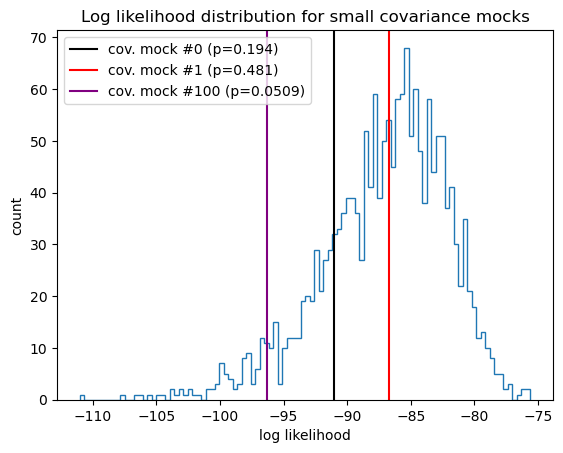

In [12]:
pv_bin_count = 100
plt.hist(log_llhs, bins=pv_bin_count, histtype='step'); plt.xlabel('log likelihood'); plt.ylabel('count'); plt.title('Log likelihood distribution for small covariance mocks');

cov_mock_index = 0
#pv_counts, pv_bins = np.histogram(np.exp(log_llhs), bins=10*pv_bin_count, density=True)
#pv_bin_widths = np.diff(pv_bins)
#integrated_pdf = pv_counts*pv_bin_widths
#pv_threshold = pv_bins[:-1] < np.exp(log_llhs[cov_mock_index])
#p_value = np.sum(integrated_pdf[pv_threshold])
pv_threshold = log_llhs < log_llhs[cov_mock_index]
p_value = np.sum(pv_threshold)/len(log_llhs)

#print(p_value, pv_threshold)
plt.axvline(log_llhs[cov_mock_index], color='black', label=f'cov. mock #{cov_mock_index} (p={p_value:.3g})'); 
p_value_0 = p_value

cov_mock_index = 1
#pv_counts, pv_bins = np.histogram(np.exp(log_llhs), bins=10*pv_bin_count, density=True)
#pv_bin_widths = np.diff(pv_bins)
#integrated_pdf = pv_counts*pv_bin_widths
#pv_threshold = pv_bins[:-1] < np.exp(log_llhs[cov_mock_index])
#p_value = np.sum(integrated_pdf[pv_threshold])
pv_threshold = log_llhs < log_llhs[cov_mock_index]
p_value = np.sum(pv_threshold)/len(log_llhs)

#print(p_value, pv_threshold)
plt.axvline(log_llhs[cov_mock_index], color='red', label=f'cov. mock #{cov_mock_index} (p={p_value:.3g})'); 


cov_mock_index = 100
#pv_counts, pv_bins = np.histogram(np.exp(log_llhs), bins=10*pv_bin_count, density=True)
#pv_bin_widths = np.diff(pv_bins)
#integrated_pdf = pv_counts*pv_bin_widths
#pv_threshold = pv_bins[:-1] < np.exp(log_llhs[cov_mock_index])
#p_value = np.sum(integrated_pdf[pv_threshold])
pv_threshold = log_llhs < log_llhs[cov_mock_index]
p_value = np.sum(pv_threshold)/len(log_llhs)

#print(p_value, pv_threshold)
plt.axvline(log_llhs[cov_mock_index], color='purple', label=f'cov. mock #{cov_mock_index} (p={p_value:.3g})'); 


plt.legend();
plt.show()
"""
plt.hist(np.exp(log_llhs), bins=10*pv_bin_count, histtype='step'); plt.xlabel('likelihood'); plt.ylabel('count'); plt.title('Likelihood distribution for small covariance mocks');
plt.axvline(np.exp(log_llhs[cov_mock_index]), color='black', label=f'cov. mock # (p={p_value_0:.3g})'); 
plt.axvline(np.exp(log_llhs[cov_mock_index]), color='red', label=f'cov. mock #{cov_mock_index} (p={p_value:.3g})'); 

plt.legend();""";

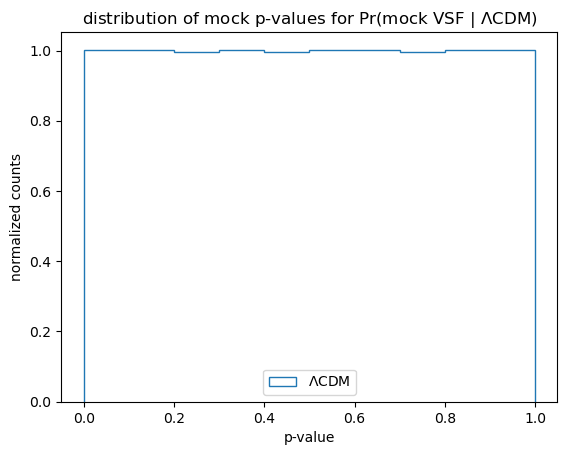

In [23]:
cov_pvals = [np.sum(log_llhs < np.sum(poisson.logpmf(vsf_phases[cov_mock_index][vsf_bin_centers<=max_bin], expected_vsf)))/len(log_llhs) for cov_mock_index in range(vsf_phases.shape[0])]

plt.hist(cov_pvals, histtype='step', density=True, label='$\\Lambda$CDM',bins=10)

plt.legend();plt.xlabel('p-value');plt.ylabel('normalized counts');plt.title('distribution of mock p-values for Pr(mock VSF | $\\Lambda$CDM)')
plt.show()

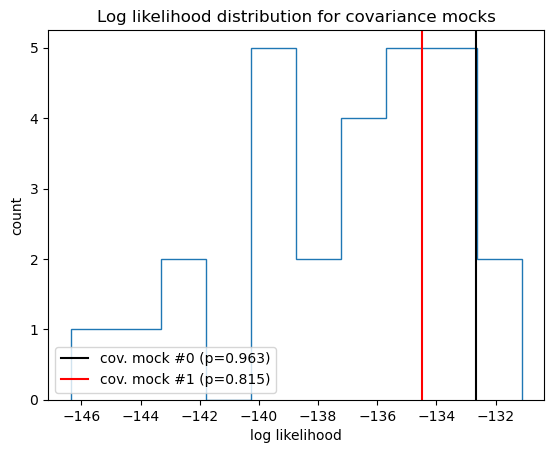

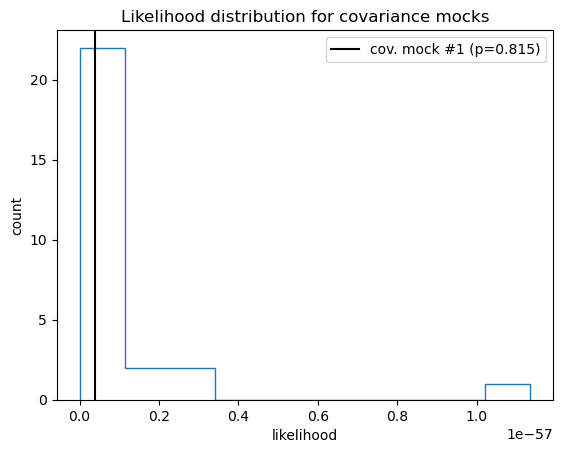

In [91]:
plt.hist(log_llhs, bins=10, histtype='step'); plt.xlabel('log likelihood'); plt.ylabel('count'); plt.title('Log likelihood distribution for covariance mocks');

cov_mock_index = 0
pv_counts, pv_bins = np.histogram(np.exp(log_llhs), bins=10, density=True)
pv_bin_widths = np.diff(pv_bins)
integrated_pdf = pv_counts*pv_bin_widths
pv_threshold = pv_bins[:-1] < np.exp(log_llhs[cov_mock_index])
p_value = np.sum(integrated_pdf[pv_threshold])
plt.axvline(log_llhs[cov_mock_index], color='black', label=f'cov. mock #{cov_mock_index} (p={p_value:.3g})'); 

cov_mock_index = 1
pv_counts, pv_bins = np.histogram(np.exp(log_llhs), bins=10, density=True)
pv_bin_widths = np.diff(pv_bins)
integrated_pdf = pv_counts*pv_bin_widths
pv_threshold = pv_bins[:-1] < np.exp(log_llhs[cov_mock_index])
p_value = np.sum(integrated_pdf[pv_threshold])
plt.axvline(log_llhs[cov_mock_index], color='red', label=f'cov. mock #{cov_mock_index} (p={p_value:.3g})'); 

plt.legend();
plt.show()

plt.hist(np.exp(log_llhs), bins=10, histtype='step'); plt.xlabel('likelihood'); plt.ylabel('count'); plt.title('Likelihood distribution for covariance mocks');
plt.axvline(np.exp(log_llhs[cov_mock_index]), color='black', label=f'cov. mock #{cov_mock_index} (p={p_value:.3g})'); 
plt.legend();

In [10]:
from scipy.stats import poisson, chisquare


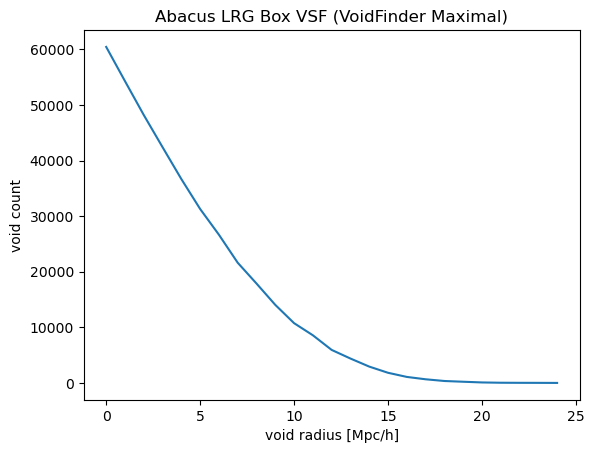

In [24]:
plt.plot(vsf_values[0][vsf_bin_centers<35]); plt.xlabel('void radius [Mpc/h]'); plt.ylabel('void count'); plt.title('Abacus LRG Box VSF (VoidFinder Maximal)');


In [15]:
# simulated data
data = vsf_values[0][vsf_bin_centers<35]

# theoretical model for specified paamters
theta = vsf_values[0][vsf_bin_centers<35]

# log likelihood
print('log likelihood =', np.sum(poisson.logpmf(data, theta)) )

# p-value?
#print (np.prod(poisson.cdf(data, theta)) )
num_model_params = 6
print (chisquare(data, theta, ddof = num_model_params) )

log likelihood = -120.11541124568171
Power_divergenceResult(statistic=np.float64(0.0), pvalue=np.float64(1.0))


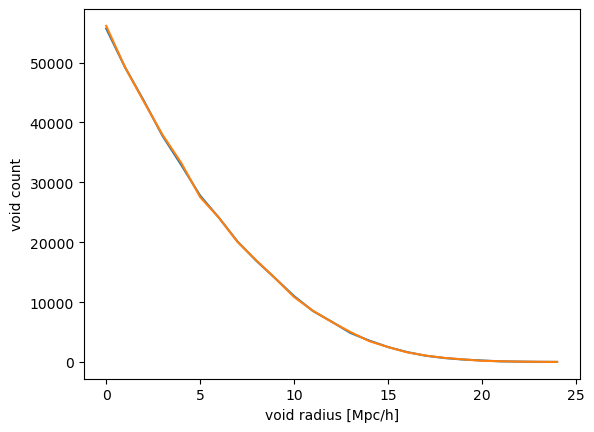

In [17]:
plt.plot(vsf_phases_base_volume[0][vsf_bin_centers<35])
plt.plot(vsf_phases_base_volume[1][vsf_bin_centers<35]); plt.xlabel('void radius [Mpc/h]'); plt.ylabel('void count');

In [17]:
#chisquare(100*np.array([16, 18, 16, 14, 12, 12]), f_exp=100*np.array([16, 16, 16, 16, 16, 8]))

In [18]:
# simulated data
data = vsf_phases_base_volume[0][vsf_bin_centers<30]

# theoretical model for specified paamters
theta = vsf_phases_base_volume[1][vsf_bin_centers<30]

# log likelihood
print('log likelihood =', np.sum(poisson.logpmf(data, theta)) )

# p-value?
#print (np.prod(poisson.cdf(data, theta)) )
num_model_params = 6
print (chisquare(data, theta, ddof = num_model_params) )

log likelihood = -122.07465482096359


ValueError: For each axis slice, the sum of the observed frequencies must agree with the sum of the expected frequencies to a relative tolerance of 1.4901161193847656e-08, but the percent differences are:
0.0014821630765077152

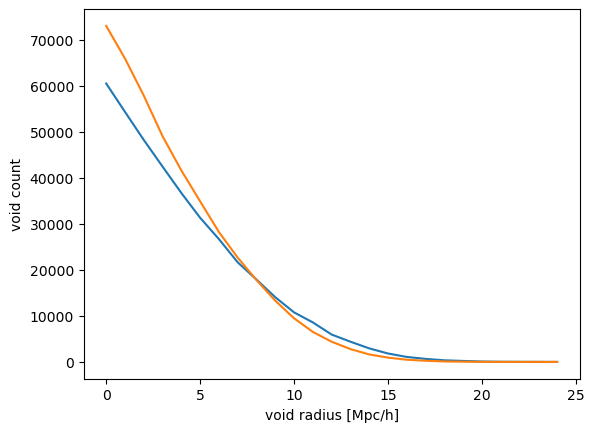

In [19]:
plt.plot(vsf_values[0][vsf_bin_centers<35])
plt.plot(vsf_values[1][vsf_bin_centers<35]); plt.xlabel('void radius [Mpc/h]'); plt.ylabel('void count');

In [21]:
# simulated data
data = vsf_values[0][vsf_bin_centers<30]

# theoretical model for specified paamters
theta = vsf_values[1][vsf_bin_centers<30]

# log likelihood
print('log likelihood =', np.sum(poisson.logpmf(data, theta)) )

# p-value?
#print (np.prod(poisson.cdf(data, theta)) )
num_model_params = 6
print (chisquare(data, theta, ddof = num_model_params) )

log likelihood = -6846.347665993156


ValueError: For each axis slice, the sum of the observed frequencies must agree with the sum of the expected frequencies to a relative tolerance of 1.4901161193847656e-08, but the percent differences are:
0.10332352911034362

In [37]:
vsf_bin_centers

array([10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5,
       21.5, 22.5, 23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5, 30.5, 31.5,
       32.5, 33.5, 34.5, 35.5, 36.5, 37.5, 38.5, 39.5])

In [36]:
vsf_phases_base_volume[0]

array([55691, 49234, 43649, 37757, 32871, 27787, 24090, 20082, 16872,
       13967, 11008,  8520,  6741,  4849,  3580,  2497,  1668,  1051,
         660,   409,   258,   106,    66,    30,    17,     2,     2,
           3,     0,     0])

In [42]:
# theory, data
# vsf_values[i]
logposterior(vsf_values[0], vsf_phases_base_volume[0], 'emulator', 'prior', vsf_bin_centers, bin_max = 35)

np.float64(-2443.328249400297)

In [29]:
np.sqrt(np.diag(vsf_cov_base_volume))

array([3.48494250e+02, 2.45763060e+02, 3.06765424e+02, 2.07678623e+02,
       2.84947459e+02, 1.68952049e+02, 1.66436927e+02, 1.61703890e+02,
       1.50398786e+02, 1.28102223e+02, 8.71753971e+01, 8.43615540e+01,
       6.40068105e+01, 5.48625581e+01, 6.35894282e+01, 3.93752493e+01,
       3.60144004e+01, 3.36172948e+01, 2.11010997e+01, 1.62615727e+01,
       1.53584892e+01, 8.56348839e+00, 6.45850220e+00, 6.15979058e+00,
       3.28078234e+00, 1.86739912e+00, 1.36813555e+00, 1.30526001e+00,
       7.00020350e-01, 2.66880256e-01])

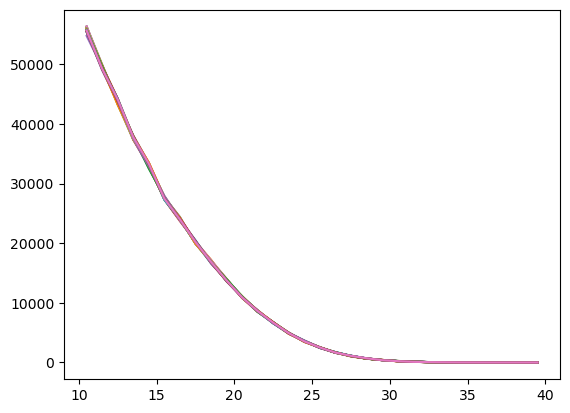

In [13]:
for i in range(0, 27):
    plt.plot(vsf_bin_centers, vsf_phases_base_volume[i])

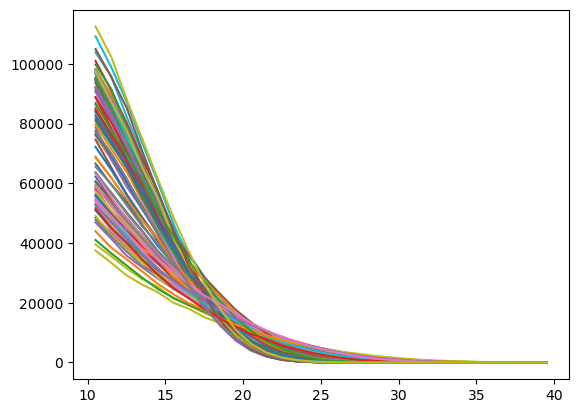

In [14]:
for i in range(0, 8898, 100):
    plt.plot(vsf_bin_centers, vsf_values[i])

In [18]:
def get_covariance(phases):
    
    covariance_matrix = np.cov(phases.T)

    return covariance_matrix


In [18]:
#vvac_cov = get_covariance(vvac_phases)

In [16]:
vgcc_cov = get_covariance(vgcc_phases)

In [130]:
vsf_phases*64

array([[58624, 49152, 41728, ...,     0,     0,     0],
       [54208, 49856, 42432, ...,     0,     0,     0],
       [55104, 47616, 45888, ...,     0,     0,     0],
       ...,
       [62144, 52032, 40192, ...,     0,     0,     0],
       [61632, 50752, 41920, ...,     0,     0,     0],
       [54784, 48192, 44352, ...,     0,     0,     0]])

In [19]:
vsf_cov = get_covariance(vsf_phases)

In [20]:
vsf_cov_base_volume=get_covariance(vsf_phases_base_volume)

In [131]:
vsf_cov_scaled = get_covariance(vsf_phases*64)

In [22]:
def plot_covariance(covariance_matrix, full_stat_name, cov_lim = 0.00005):

    plt.imshow(covariance_matrix, origin='lower', cmap = 'PiYG', vmin = -cov_lim, vmax = cov_lim)
    plt.colorbar()
    plt.title('Covariance matrix for ' + full_stat_name)
    plt.xlabel('data vector bin (i)')
    plt.ylabel('data vector bin (j)')

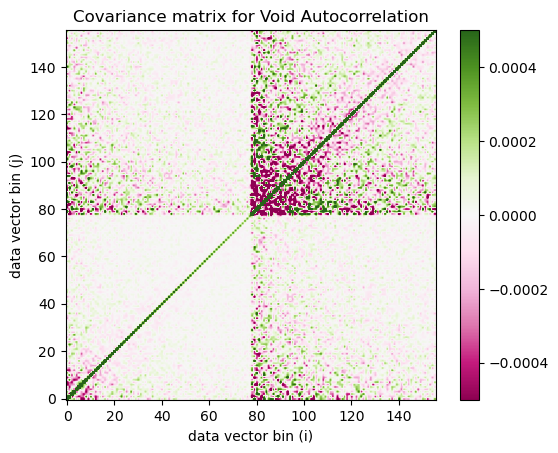

In [23]:
#plot_covariance(vvac_cov, 'Void Autocorrelation', cov_lim = 0.0005)

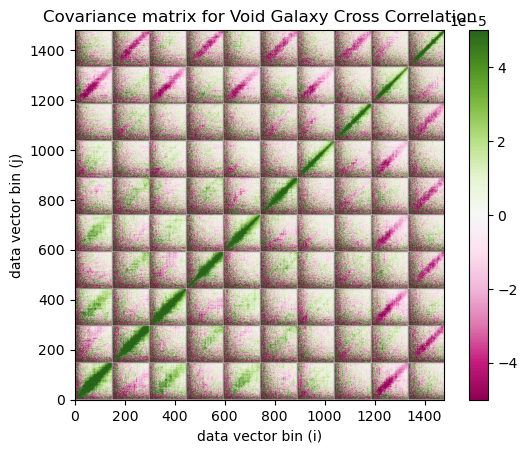

In [21]:
plot_covariance(vgcc_cov, 'Void Galaxy Cross Correlation', cov_lim = 0.00005)

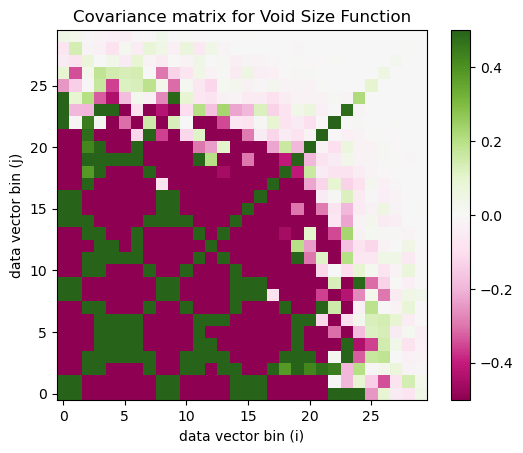

In [23]:
plot_covariance(vsf_cov, 'Void Size Function', cov_lim = .5)

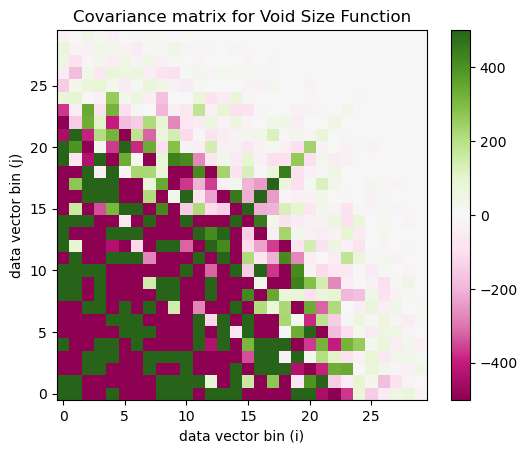

In [108]:
plot_covariance(vsf_cov_base_volume, 'Void Size Function', cov_lim = 500)

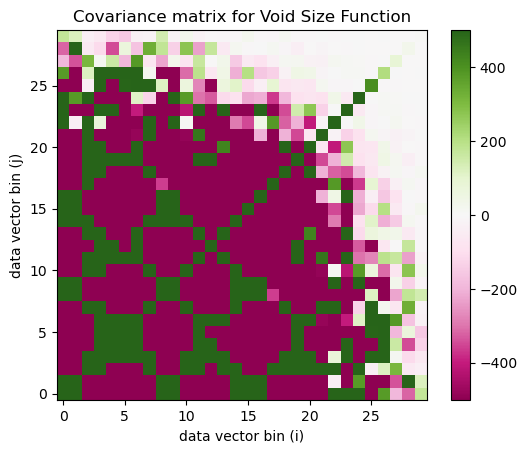

In [133]:
plot_covariance(vsf_cov_scaled, 'Void Size Function', cov_lim =500)

In [104]:
def run_training(values, bin_centers, points, stat_name, point_names, covariance_matrix, use_full = False):
    
    model_dir = f'/global/homes/h/hrincon/ACM/models/{stat_name}/'

    # grid data of shape (nmocks, ...)
    lhc_y = values
    # bin centers
    s = bin_centers
    # parameter values of shape (nmocks, nparams)
    prior_min = np.min(points,axis=0)
    prior_max = np.max(points,axis=0)
    lhc_x = (points - prior_min)/(prior_max-prior_min)

    select_test = np.full(lhc_y.shape[0],False, dtype='bool')
    if not use_full:
        select_test[::10]=True
    idx_train = (np.arange(lhc_y.shape[0])[~select_test]).tolist()
    idx_test = (np.arange(lhc_y.shape[0])[select_test]).tolist()

    val_loss, model, early_stop_callback = TrainFCN(
        lhc_x, lhc_y, idx_train,
        learning_rate=1.e-3,
        n_hidden=[512, 512, 512, 512],
        dropout_rate=0.,
        weight_decay=0,
        covariance_matrix=covariance_matrix,
        model_dir=model_dir
    )
    
    return val_loss, model, early_stop_callback

def TrainFCN(lhc_x, lhc_y, idx_train, learning_rate, n_hidden, dropout_rate, weight_decay, covariance_matrix,
    model_dir=None):
    final_model = False
    apply_transform = True
    select_filters = {}
    slice_filters = {}

    if apply_transform:
        transform = ArcsinhTransform()
        # transform = LogTransform()
        lhc_y = transform.transform(lhc_y)
    else:
        transform = None
        

    #nhod = int(len(lhc_y) / 85)
    ntot = len(lhc_y)

    if final_model:
        idx_train = list(range(lhc_y.shape[0]))#list(range(ntot))
    else:
        #idx_train = list(range(nhod * 6, ntot))
        pass
        

    print(f'Using {len(idx_train)} samples for training')

    lhc_train_x = lhc_x[idx_train]
    lhc_train_y = lhc_y[idx_train]

    train_mean = np.mean(lhc_train_y, axis=0)
    train_std = np.std(lhc_train_y, axis=0)

    train_mean_x = np.mean(lhc_train_x, axis=0)
    train_std_x = np.std(lhc_train_x, axis=0)

    
    data = ArrayDataModule(x=torch.Tensor(lhc_train_x),
                        y=torch.Tensor(lhc_train_y), 
                        val_fraction=0.1, batch_size=128,
                        num_workers=11)
    data.setup()

    model = FCN(
            n_input=data.n_input,
            n_output=data.n_output,
            n_hidden=n_hidden,
            dropout_rate=dropout_rate, 
            learning_rate=learning_rate,
            scheduler_patience=10,
            scheduler_factor=0.5,
            scheduler_threshold=1.e-6,
            weight_decay=weight_decay,
            act_fn='learned_sigmoid',
            # act_fn='SiLU',
            loss='GaussianNLoglike',
            #loss='mae',
            training=True,
            mean_output=train_mean,
            std_output=train_std,
            mean_input=train_mean_x,
            std_input=train_std_x,
            transform_output=transform,
            standarize_output=True,
            #coordinates=coordinates,
            covariance_matrix=covariance_matrix,
        
        )

    model_dir = './' if model_dir is None else model_dir
    Path(model_dir).mkdir(parents=True, exist_ok=True)
    print(f'Saving model to {model_dir}')

    val_loss, model, early_stop_callback = train.fit(
        data=data, model=model,
        model_dir=model_dir,
        max_epochs=5000,
        devices=1,
        logger ='tensorboard',
        log_dir = '/global/homes/h/hrincon/ACM/tensorboardlog',
    )
    return val_loss, model, early_stop_callback


In [27]:
#run_training(vvac_values, vvac_bin_centers, vvac_points, 'vvac')

In [30]:
vgcc_cov.shape

(1480, 1480)

In [29]:
vgcc_values.shape

(8898, 1480)

In [114]:
# cov w. vsf_cov
run_training(vsf_values, vsf_bin_centers, vsf_points, 'vsf_cov', point_names, vsf_cov)

/tmp/ipykernel_161901/994919842.py:105: DeprecatedWarning: fit is deprecated as of Kept for compatibility, use train_fcn instead.
  val_loss, model, early_stop_callback = train.fit(
Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Using 8008 samples for training
Saving model to /global/homes/h/hrincon/ACM/models/vsf_cov/


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mlp      │ Sequential       │  818 K │ train │     0 │
│ 1 │ loss_fct │ GaussianNLoglike │      0 │ train │     0 │
└───┴──────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 818 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 818 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 15                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Metric val_loss improved. New best score: 89.494
Metric val_loss improved by 12.724 >= min_delta = 1e-07. New best score: 76.770
Metric val_loss improved by 20.464 >= min_delta = 1e-07. New best score: 56.306
Metric val_loss improved by 1.809 >= min_delta = 1e-07. New best score: 54.498
Metric val_loss improved by 4.487 >= min_delta = 1e-07. New best score: 50.011
Metric val_loss improved by 0.385 >= min_delta = 1e-07. New best score: 49.626
Monitored metric val_loss did not improve in the last 30 records. Best score: 49.626. Signaling Trainer to stop.


(49.6256217956543,
 FCN(
   (mlp): Sequential(
     (mlp0): Linear(in_features=20, out_features=512, bias=True)
     (act0): LearnedSigmoid()
     (dropout0): Dropout(p=0.0, inplace=False)
     (mlp1): Linear(in_features=512, out_features=512, bias=True)
     (act1): LearnedSigmoid()
     (dropout1): Dropout(p=0.0, inplace=False)
     (mlp2): Linear(in_features=512, out_features=512, bias=True)
     (act2): LearnedSigmoid()
     (dropout2): Dropout(p=0.0, inplace=False)
     (mlp3): Linear(in_features=512, out_features=512, bias=True)
     (act3): LearnedSigmoid()
     (dropout3): Dropout(p=0.0, inplace=False)
     (mlp4): Linear(in_features=512, out_features=30, bias=True)
   )
   (loss_fct): GaussianNLoglike()
 ),
 <lightning.pytorch.callbacks.early_stopping.EarlyStopping at 0x7f1ccc15c080>)

In [117]:
# cov w. vsf_cov_base_volume
run_training(vsf_values, vsf_bin_centers, vsf_points, 'vsf_cov_base_volume', point_names, vsf_cov_base_volume)

/tmp/ipykernel_161901/994919842.py:105: DeprecatedWarning: fit is deprecated as of Kept for compatibility, use train_fcn instead.
  val_loss, model, early_stop_callback = train.fit(
Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Using 8008 samples for training
Saving model to /global/homes/h/hrincon/ACM/models/vsf_cov_base_volume/


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mlp      │ Sequential       │  818 K │ train │     0 │
│ 1 │ loss_fct │ GaussianNLoglike │      0 │ train │     0 │
└───┴──────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 818 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 818 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 15                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Metric val_loss improved. New best score: -17835585062305792.000
Metric val_loss improved by 43733031014325288960.000 >= min_delta = 1e-07. New best score: -43750865092927815680.000
Metric val_loss improved by 57163789847981195264.000 >= min_delta = 1e-07. New best score: -100914654940909010944.000
Metric val_loss improved by 242596245552496640.000 >= min_delta = 1e-07. New best score: -101157251186461507584.000
Metric val_loss improved by 360639813910528.000 >= min_delta = 1e-07. New best score: -101157611826275418112.000


Epoch 25/4999 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━ 40/57 0:00:01 • 0:00:01 101.10it/s v_num: 10.000

Monitored metric val_loss did not improve in the last 30 records. Best score: -101157611826275418112.000. Signaling Trainer to stop.


(-1.0115761182627542e+20,
 FCN(
   (mlp): Sequential(
     (mlp0): Linear(in_features=20, out_features=512, bias=True)
     (act0): LearnedSigmoid()
     (dropout0): Dropout(p=0.0, inplace=False)
     (mlp1): Linear(in_features=512, out_features=512, bias=True)
     (act1): LearnedSigmoid()
     (dropout1): Dropout(p=0.0, inplace=False)
     (mlp2): Linear(in_features=512, out_features=512, bias=True)
     (act2): LearnedSigmoid()
     (dropout2): Dropout(p=0.0, inplace=False)
     (mlp3): Linear(in_features=512, out_features=512, bias=True)
     (act3): LearnedSigmoid()
     (dropout3): Dropout(p=0.0, inplace=False)
     (mlp4): Linear(in_features=512, out_features=30, bias=True)
   )
   (loss_fct): GaussianNLoglike()
 ),
 <lightning.pytorch.callbacks.early_stopping.EarlyStopping at 0x7f1ccc2f9ca0>)

In [134]:
# cov w. vsf_cov_scaled
run_training(vsf_values, vsf_bin_centers, vsf_points, 'vsf_cov_scaled', point_names, vsf_cov_scaled)

/tmp/ipykernel_161901/994919842.py:105: DeprecatedWarning: fit is deprecated as of Kept for compatibility, use train_fcn instead.
  val_loss, model, early_stop_callback = train.fit(
Seed set to 42


Using 8008 samples for training
Saving model to /global/homes/h/hrincon/ACM/models/vsf_cov_scaled/


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mlp      │ Sequential       │  818 K │ train │     0 │
│ 1 │ loss_fct │ GaussianNLoglike │      0 │ train │     0 │
└───┴──────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 818 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 818 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 15                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Metric val_loss improved. New best score: 0.021
Metric val_loss improved by 0.004 >= min_delta = 1e-07. New best score: 0.017
Metric val_loss improved by 0.003 >= min_delta = 1e-07. New best score: 0.014
Metric val_loss improved by 0.001 >= min_delta = 1e-07. New best score: 0.012
Metric val_loss improved by 0.000 >= min_delta = 1e-07. New best score: 0.012
Monitored metric val_loss did not improve in the last 30 records. Best score: 0.012. Signaling Trainer to stop.


(0.012020698748528957,
 FCN(
   (mlp): Sequential(
     (mlp0): Linear(in_features=20, out_features=512, bias=True)
     (act0): LearnedSigmoid()
     (dropout0): Dropout(p=0.0, inplace=False)
     (mlp1): Linear(in_features=512, out_features=512, bias=True)
     (act1): LearnedSigmoid()
     (dropout1): Dropout(p=0.0, inplace=False)
     (mlp2): Linear(in_features=512, out_features=512, bias=True)
     (act2): LearnedSigmoid()
     (dropout2): Dropout(p=0.0, inplace=False)
     (mlp3): Linear(in_features=512, out_features=512, bias=True)
     (act3): LearnedSigmoid()
     (dropout3): Dropout(p=0.0, inplace=False)
     (mlp4): Linear(in_features=512, out_features=30, bias=True)
   )
   (loss_fct): GaussianNLoglike()
 ),
 <lightning.pytorch.callbacks.early_stopping.EarlyStopping at 0x7f1cc57f7c50>)

In [100]:
# no cov
run_training(vsf_values, vsf_bin_centers, vsf_points, 'vsf', point_names, vsf_cov)

/tmp/ipykernel_161901/1385563591.py:105: DeprecatedWarning: fit is deprecated as of Kept for compatibility, use train_fcn instead.
  val_loss, model, early_stop_callback = train.fit(
Seed set to 42


Using 8008 samples for training
Saving model to /global/homes/h/hrincon/ACM/models/vsf/


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ mlp      │ Sequential │  818 K │ train │     0 │
│ 1 │ loss_fct │ L1Loss     │      0 │ train │     0 │
└───┴──────────┴────────────┴────────┴───────┴───────┘

Trainable params: 818 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 818 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 15                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Metric val_loss improved. New best score: 0.227
Metric val_loss improved by 0.085 >= min_delta = 1e-07. New best score: 0.142
Metric val_loss improved by 0.008 >= min_delta = 1e-07. New best score: 0.133
Metric val_loss improved by 0.016 >= min_delta = 1e-07. New best score: 0.117
Metric val_loss improved by 0.007 >= min_delta = 1e-07. New best score: 0.110
Metric val_loss improved by 0.009 >= min_delta = 1e-07. New best score: 0.101
Metric val_loss improved by 0.001 >= min_delta = 1e-07. New best score: 0.099
Metric val_loss improved by 0.003 >= min_delta = 1e-07. New best score: 0.096
Metric val_loss improved by 0.002 >= min_delta = 1e-07. New best score: 0.094
Metric val_loss improved by 0.001 >= min_delta = 1e-07. New best score: 0.093
Metric val_loss improved by 0.002 >= min_delta = 1e-07. New best score: 0.091
Metric val_loss improved by 0.004 >= min_delta = 1e-07. New best score: 0.087
Metric val_loss improved by 0.002 >= min_delta = 1e-07. New best score: 0.085
Metric val_loss 

(0.08382415026426315,
 FCN(
   (mlp): Sequential(
     (mlp0): Linear(in_features=20, out_features=512, bias=True)
     (act0): LearnedSigmoid()
     (dropout0): Dropout(p=0.0, inplace=False)
     (mlp1): Linear(in_features=512, out_features=512, bias=True)
     (act1): LearnedSigmoid()
     (dropout1): Dropout(p=0.0, inplace=False)
     (mlp2): Linear(in_features=512, out_features=512, bias=True)
     (act2): LearnedSigmoid()
     (dropout2): Dropout(p=0.0, inplace=False)
     (mlp3): Linear(in_features=512, out_features=512, bias=True)
     (act3): LearnedSigmoid()
     (dropout3): Dropout(p=0.0, inplace=False)
     (mlp4): Linear(in_features=512, out_features=30, bias=True)
   )
   (loss_fct): L1Loss()
 ),
 <lightning.pytorch.callbacks.early_stopping.EarlyStopping at 0x7f1ccc2dd3d0>)

# VGCC

In [35]:
run_training(vgcc_values, vgcc_bin_centers, vgcc_points, 'vgcc', point_names, vgcc_cov)

Seed set to 42


Using 8008 samples for training
Saving model to /global/homes/h/hrincon/ACM/models/vgcc/r_bins/partial/


/global/u2/h/hrincon/.local/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /global/common/software/desi/users/adematti/perlmutt ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type       ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ mlp      │ Sequential │  1.6 M │ train │
│ 1 │ loss_fct │ L1Loss     │      0 │ train │
└───┴──────────┴────────────┴────────┴───────┘

Trainable params: 1.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.6 M                                                                                                
Total estimated model params size (MB): 6                                                                          
Modules in train mode: 15                                                                                          
Modules in eval mode: 0

Output()

Metric val_loss improved. New best score: 0.007
Metric val_loss improved by 0.000 >= min_delta = 1e-07. New best score: 0.007
Monitored metric val_loss did not improve in the last 30 records. Best score: 0.007. Signaling Trainer to stop.


(0.007095664739608765,
 FCN(
   (mlp): Sequential(
     (mlp0): Linear(in_features=20, out_features=512, bias=True)
     (act0): LearnedSigmoid()
     (dropout0): Dropout(p=0.0, inplace=False)
     (mlp1): Linear(in_features=512, out_features=512, bias=True)
     (act1): LearnedSigmoid()
     (dropout1): Dropout(p=0.0, inplace=False)
     (mlp2): Linear(in_features=512, out_features=512, bias=True)
     (act2): LearnedSigmoid()
     (dropout2): Dropout(p=0.0, inplace=False)
     (mlp3): Linear(in_features=512, out_features=512, bias=True)
     (act3): LearnedSigmoid()
     (dropout3): Dropout(p=0.0, inplace=False)
     (mlp4): Linear(in_features=512, out_features=1480, bias=True)
   )
   (loss_fct): L1Loss()
 ),
 <lightning.pytorch.callbacks.early_stopping.EarlyStopping at 0x7f0e5a4be360>)

In [17]:
run_training(vgcc_values, vgcc_bin_centers, vgcc_points, 'vgcc', point_names, vgcc_cov)

Using 8008 samples for training


Seed set to 42


Saving model to /global/homes/h/hrincon/ACM/models/vgcc/r_bins/partial/


AttributeError: module 'wandb' has no attribute 'init'

In [193]:
def load_training(values, points, stat_name, use_full=False):
    select_test = np.full(values.shape[0],False, dtype='bool') 
    if not use_full:
        select_test[::10]=True
    idx_test = (np.arange(values.shape[0])[select_test]).tolist()


    model_dir = f'/global/homes/h/hrincon/ACM/models/{stat_name}/'
    
    model = FCN.load_from_checkpoint(f'{model_dir}/last.ckpt', strict=True, weights_only=False)
    model = model.to(torch.device("cpu"))
    prior_min = np.min(points,axis=0)
    prior_max = np.max(points,axis=0)
    points = (points - prior_min)/(prior_max-prior_min)

    with torch.no_grad():
        if use_full:
            prediction = model.get_prediction(torch.Tensor(points))
        else:
            prediction = model.get_prediction(torch.Tensor(points[idx_test]))
            
        prediction = prediction.numpy()
    return model, prediction
        

def get_prediction(points):

    prior_min = np.min(points,axis=0)
    prior_max = np.max(points,axis=0)
    params = (points - prior_min)/(prior_max-prior_min)
    
    with torch.no_grad():
        pred_test_y  = model.get_prediction(torch.Tensor(points))
    pred_test_y = pred_test_y.numpy()

    return pred_test_y


In [57]:
vvac_model, vvac_prediction = load_training(vvac_values, vvac_points, 'vvac')

In [137]:
vgcc_model, vgcc_prediction = load_training(vgcc_values, vgcc_points, 'vgcc')

In [32]:
torch.serialization.add_safe_globals([ArcsinhTransform])

In [36]:
torch.serialization.add_safe_globals([np._core.multiarray._reconstruct])

In [38]:
torch.serialization.add_safe_globals([np.ndarray])

In [40]:
torch.serialization.add_safe_globals([np.dtype])

In [142]:
vsf_model, vsf_prediction = load_training(vsf_values, vsf_points, 'vsf')

In [115]:
vsf_model, vsf_prediction = load_training(vsf_values, vsf_points, 'vsf_cov')

In [118]:
vsf_model, vsf_prediction = load_training(vsf_values, vsf_points, 'vsf_cov_base_volume')

In [139]:
vsf_model, vsf_prediction = load_training(vsf_values, vsf_points, 'vsf_cov_scaled')

In [124]:
def plot_emulator_error(prediction, values, covariance_matrix, full_stat_name, bin_centers=None, xlabel=None):
    
    select_test = np.full(values.shape[0],False, dtype='bool') 
    select_test[::10]=True
    idx_test = (np.arange(values.shape[0])[select_test]).tolist()

    if bin_centers is None:
        bin_centers = np.arange(values.shape[1])
        xlabel='data vector bin (i)'
    
    emulator_error = (prediction - values[idx_test])/np.sqrt(np.diag(covariance_matrix))
    q68 = np.quantile(emulator_error, [0.16, 0.84], axis=0)
    q95 = np.quantile(emulator_error, [0.025, 0.975], axis=0)
    q99 = np.quantile(emulator_error, [0.005, 0.995], axis=0)
    
    plt.axhline(1, linestyle = ':', alpha = 0.5, color = 'k')
    plt.axhline(-1, linestyle = ':', alpha = 0.5, color = 'k')
    plt.axhline(0, linestyle = ':', alpha = 0.5, color = 'k')
    
    plt.fill_between(bin_centers, q95[0], q95[1], alpha=0.5, label='95% quantile of test set',)
    plt.fill_between(bin_centers, q68[0], q68[1], alpha=0.5, label='68% quantile of test set',) 
    plt.legend()
    plt.title('Emulator Error for '+full_stat_name)
    plt.ylabel(f'(predicted VSF - true VSF) / STD( VSF of alt phase mocks )')
    plt.xlabel(xlabel)
    #plt.ylim(-4,4)
    #plt.xlim(10.5,35.5)
    #plt.show();


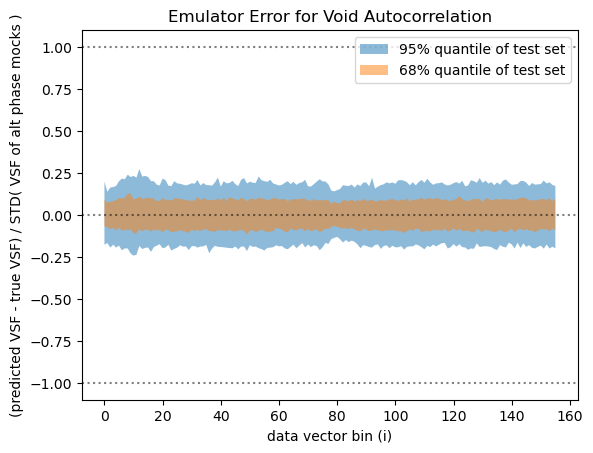

In [34]:
plot_emulator_error(vvac_prediction, vvac_values, vvac_cov, 'Void Autocorrelation')

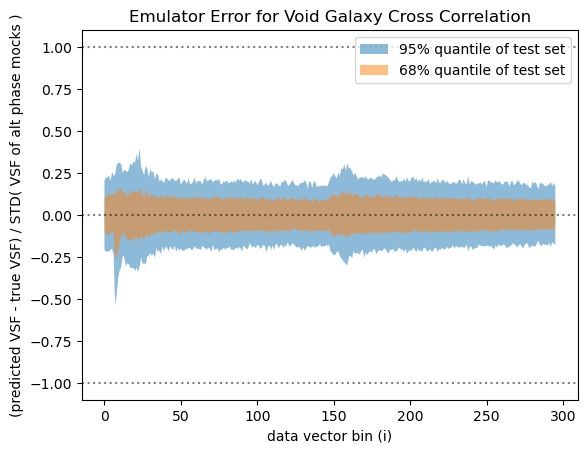

In [31]:
plot_emulator_error(vgcc_prediction, vgcc_values, vgcc_cov, 'Void Galaxy Cross Correlation')

In [121]:
vsf_bin_centers

array([10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5,
       21.5, 22.5, 23.5, 24.5, 25.5, 26.5, 27.5, 28.5, 29.5, 30.5, 31.5,
       32.5, 33.5, 34.5, 35.5, 36.5, 37.5, 38.5, 39.5])

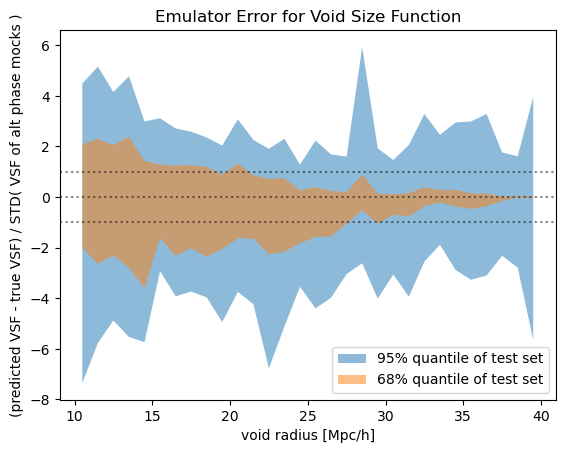

In [125]:
# no cov
plot_emulator_error(vsf_prediction, vsf_values, vsf_cov_base_volume, 'Void Size Function', 
                    bin_centers=vsf_bin_centers, xlabel = 'void radius [Mpc/h]')

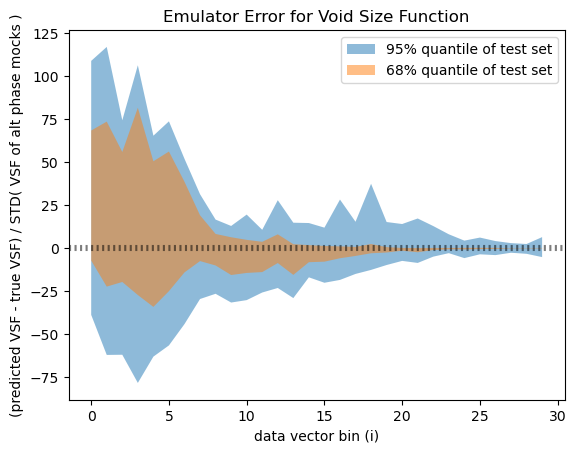

In [116]:
# cov w vsf_cov
plot_emulator_error(vsf_prediction, vsf_values, vsf_cov_base_volume, 'Void Size Function')

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20251214-1.0.0/conda/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


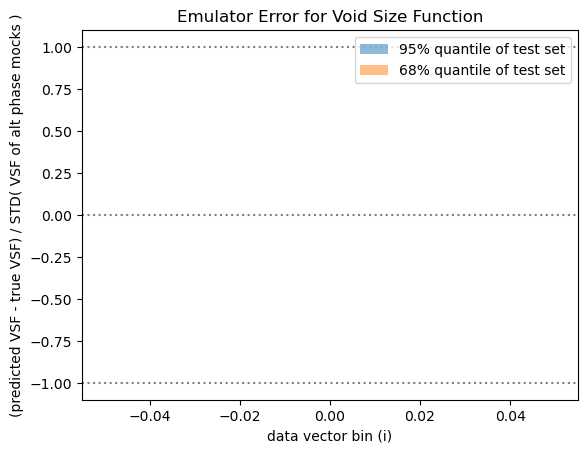

In [119]:
# cov with vsf_cov_base_volume
plot_emulator_error(vsf_prediction, vsf_values, vsf_cov_base_volume, 'Void Size Function')

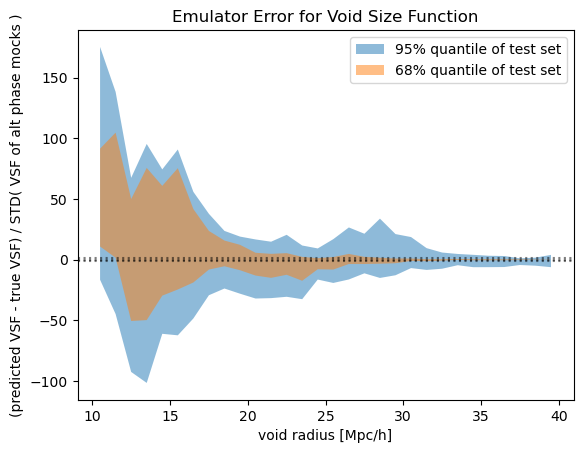

In [140]:
# cov with vsf_cov_scaled
plot_emulator_error(vsf_prediction, vsf_values, vsf_cov_base_volume, 'Void Size Function', 
                    bin_centers=vsf_bin_centers, xlabel = 'void radius [Mpc/h]')

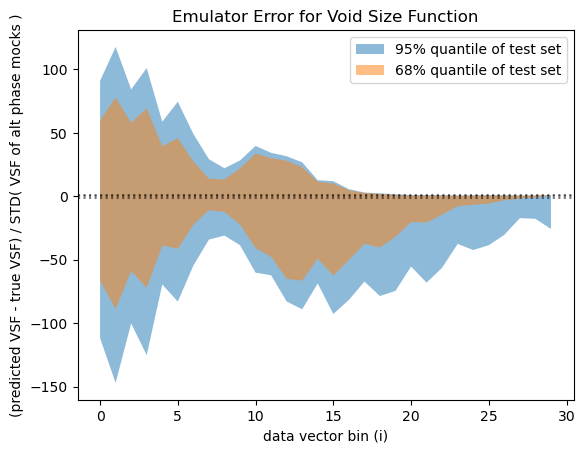

In [28]:
# covariance in training
plot_emulator_error(vsf_prediction, vsf_values, vsf_cov_base_volume, 'Void Size Function')

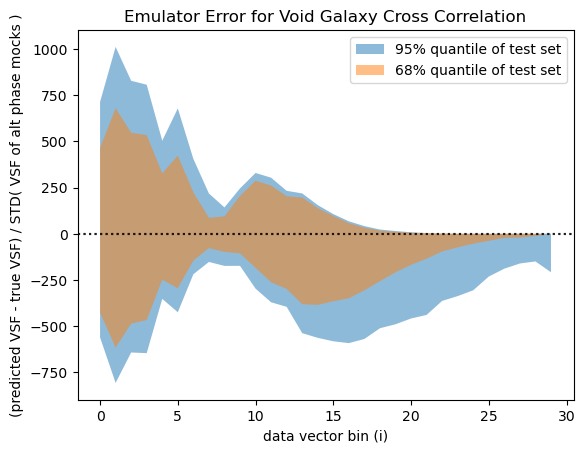

In [29]:
# no covariance in training
plot_emulator_error(vsf_prediction, vsf_values, vsf_cov, 'Void Galaxy Cross Correlation')

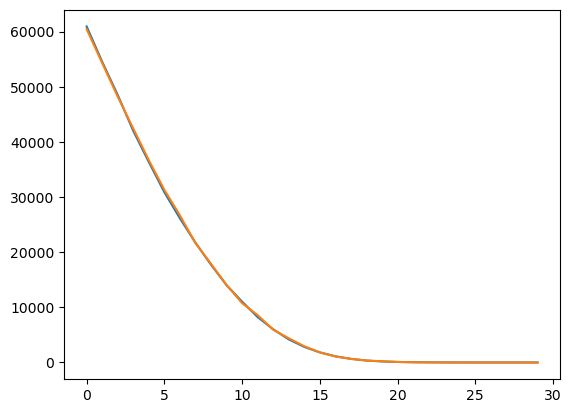

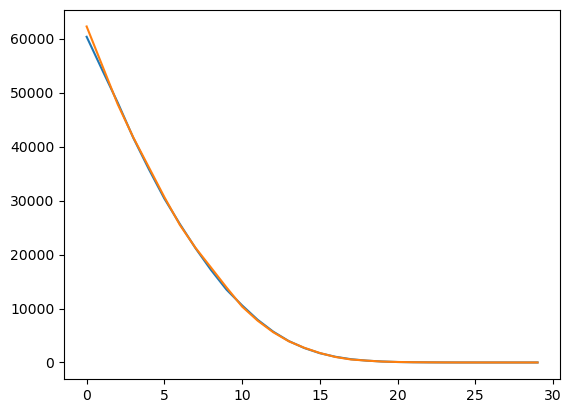

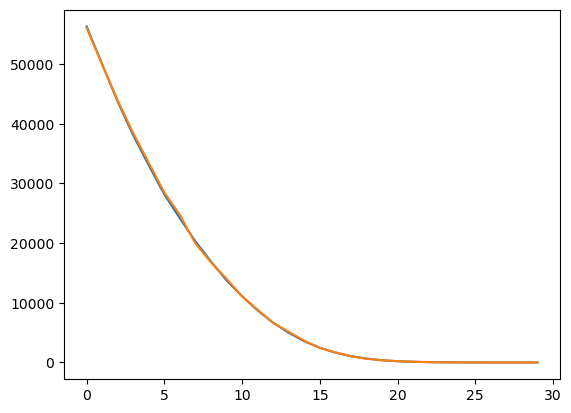

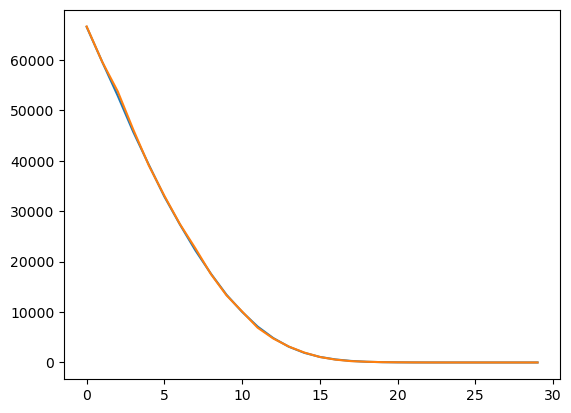

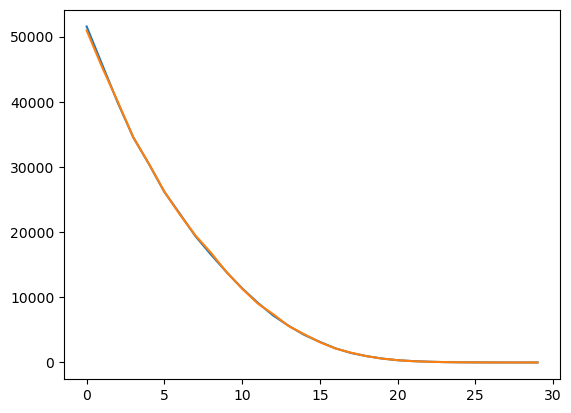

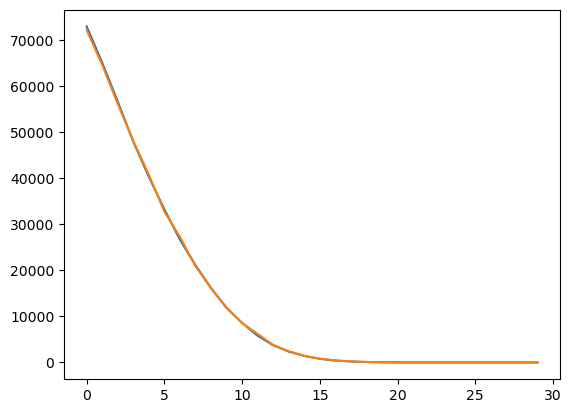

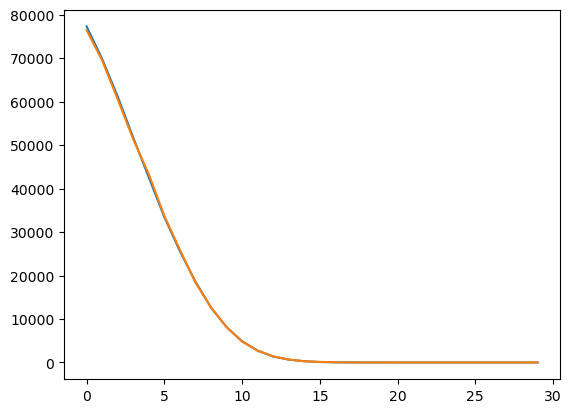

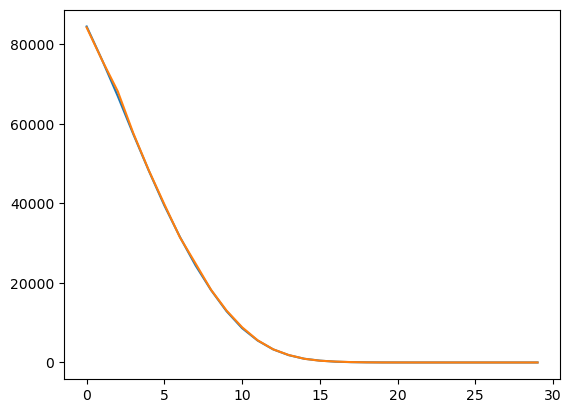

In [103]:
def tmp(prediction, values, covariance_matrix, full_stat_name):
    
    select_test = np.full(values.shape[0],False, dtype='bool') 
    select_test[::10]=True
    idx_test = (np.arange(values.shape[0])[select_test]).tolist()

    bin_centers = np.arange(values.shape[1])
    
    emulator_error = (prediction - values[idx_test])
    for i in range(0,800, 100):
        plt.plot(np.arange(len(prediction[0])), prediction[i])
        plt.plot(np.arange(len(prediction[0])), values[idx_test][i])
        plt.show()
tmp(vsf_prediction, vsf_values, vsf_cov, 'Void Galaxy Cross Correlation')

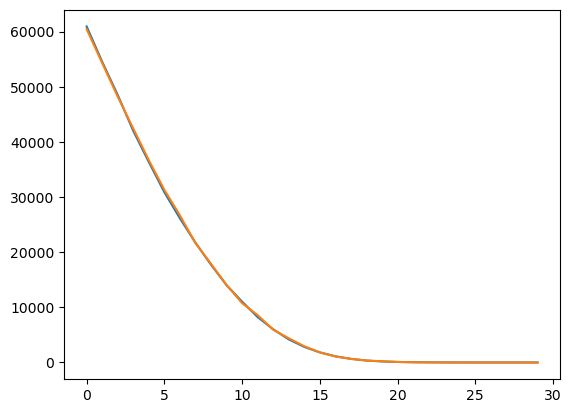

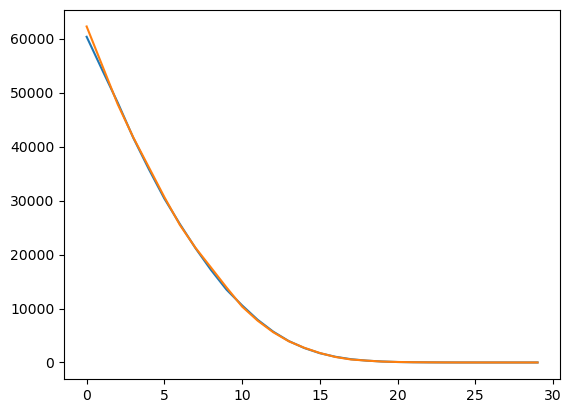

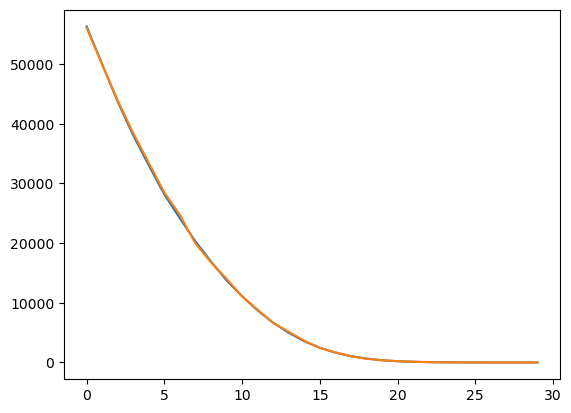

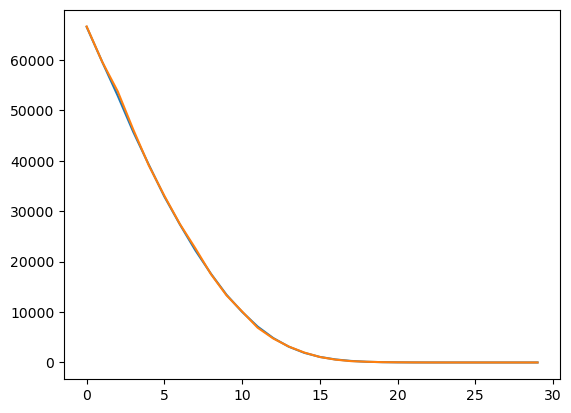

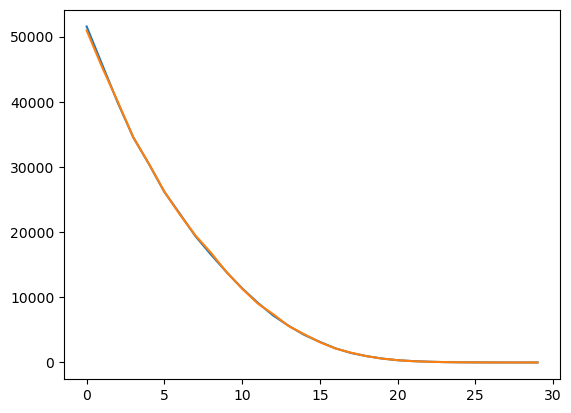

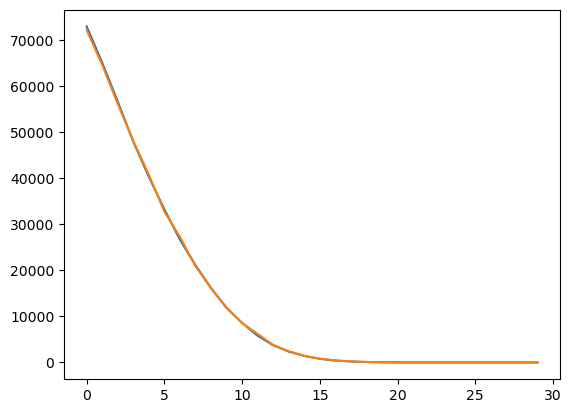

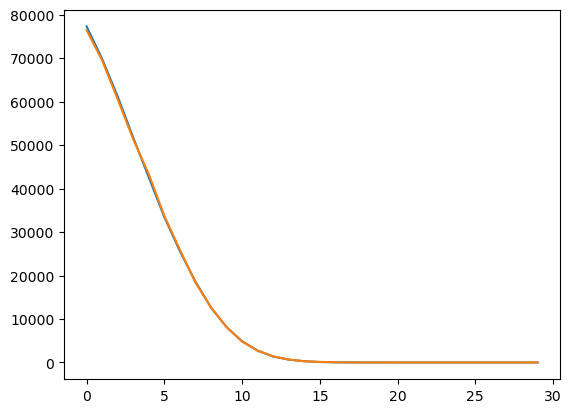

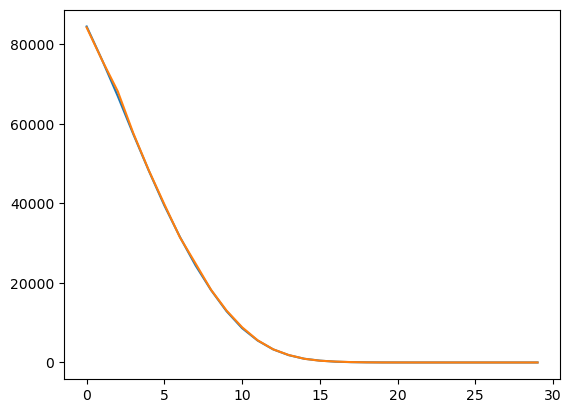

In [126]:
def tmp(prediction, values, covariance_matrix, full_stat_name):
    
    select_test = np.full(values.shape[0],False, dtype='bool') 
    select_test[::10]=True
    idx_test = (np.arange(values.shape[0])[select_test]).tolist()

    bin_centers = np.arange(values.shape[1])
    
    emulator_error = (prediction - values[idx_test])
    for i in range(0,800, 100):
        plt.plot(np.arange(len(prediction[0])), prediction[i])
        plt.plot(np.arange(len(prediction[0])), values[idx_test][i])
        plt.show()
tmp(vsf_prediction, vsf_values, vsf_cov, 'Void Galaxy Cross Correlation')

(0.0, 150.0)

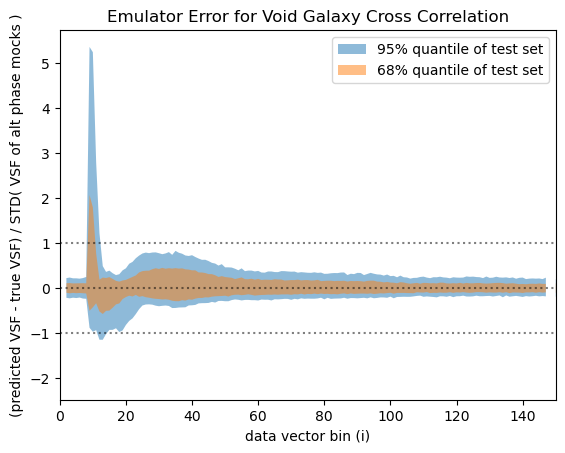

In [138]:
# r_bins no monopole ...
plot_emulator_error(vgcc_prediction, vgcc_values, vgcc_cov, 'Void Galaxy Cross Correlation')
plt.xlim(0,150)

(0.0, 150.0)

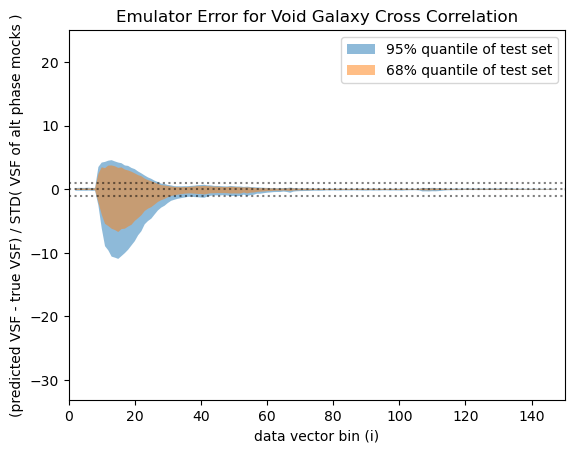

In [104]:
# r_bins ...
plot_emulator_error(vgcc_prediction, vgcc_values, vgcc_cov, 'Void Galaxy Cross Correlation')
plt.xlim(0,150)

In [35]:
# try seperate emulators for monopole and quadrupole?

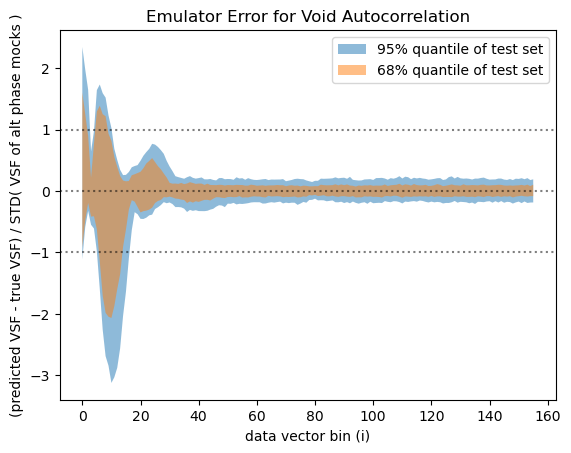

In [36]:
plot_emulator_error(vvac_prediction, vvac_values, vvac_cov, 'Void Autocorrelation')

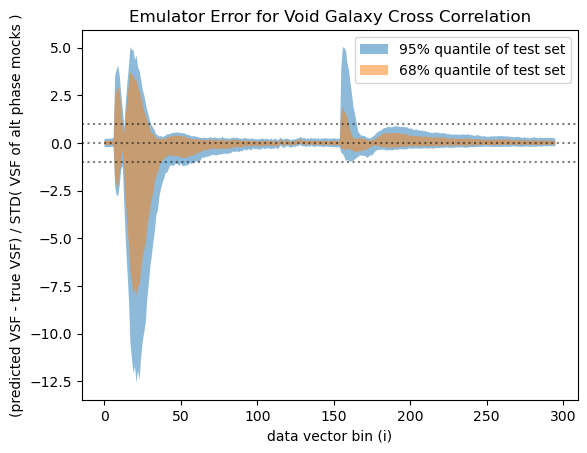

In [37]:
plot_emulator_error(vgcc_prediction, vgcc_values, vgcc_cov, 'Void Galaxy Cross Correlation')

In [93]:
def plot_chains(result, Nsamples, Nburnin):
    fig, axes = plt.subplots(len(result[0]),1, figsize=(10, 2*(len(result[0]))), sharex=True,
                             gridspec_kw={'hspace':0.1})
    #bad_samples = sampler.get_chain()[:,:,:]
    good_walkers = result[2] > 0
    bad_samples = result[1][:,good_walkers,:]
    #bad_blobs = sampler.get_blobs()
    
    
    for i in range(result[1].shape[2]):
        ax = axes[i]
        dat = bad_samples[:,:,i]
        ax.plot(dat, 'k', alpha=0.3)
        ax.set(xlim=(0, Nsamples+Nburnin+1), ylabel=result[0][i])
        ax.yaxis.set_label_coords(-0.11, 0.5) 
        ax.axvline(Nburnin)
    """ax = axes[-1]
    dat = result[3][:,good_walkers]
    ax.plot(dat, 'k', alpha=0.3)
    ax.set(xlim=(0,2500+1), ylabel='$\\sigma_8$')
    ax.yaxis.set_label_coords(-0.11, 0.5) 
    ax.axvline(500)"""
    
    axes[-1].set_xlabel('step number')
    #fig.tight_layout()

from scipy.special import factorial, loggamma

def logposterior(theta, data, emulator, prior, bin_min, bin_max, covariance_matrix):
    #theta must be a list or array, not a tuple
    theta = np.array(theta)
    
    lp = logprior(theta, prior) # get the prior
        
    if not np.isfinite(lp):
        return -np.inf

    return lp + loglikelihood(theta, data, emulator, bin_min, bin_max, covariance_matrix)


def loglikelihood(theta, data, emulator, bin_min, bin_max, covariance_matrix): #

    theta_full = np.array(data_params)

    if parameter_set == 'set_a':
        theta_full[1] = theta[0] #omega_cdm
        theta_full[2] = theta[1] #ns
        theta_full[7] = theta[2] #sigma_8
    elif parameter_set == 'set_aa':
        theta_full[1] = theta[0] #omega_cdm
        theta_full[7] = theta[1] #sigma_8
    elif parameter_set == 'set_ab':
        theta_full[2] = theta[0] #ns
        theta_full[7] = theta[1] #sigma_8
    elif parameter_set == 'set_b':
        theta_full[0] = theta[0] #omega_b
        theta_full[1] = theta[1] #omega_cdm
        theta_full[2] = theta[2] #ns
        theta_full[7] = theta[3] #sigma_8
    elif parameter_set == 'set_c':
        theta_full[0] = theta[0] #omega_b
        theta_full[1] = theta[1] #omega_cdm
        theta_full[2] = theta[2] #ns
        theta_full[5] = theta[3] #w0
        theta_full[6] = theta[4] #wa
        theta_full[7] = theta[5] #sigma_8
        theta = np.array([omega_b, omega_cdm, ns, 0., 2.0328, w0, wa, sigma_8, 12.79, 0.21])
    elif parameter_set == 'set_d':
        theta_full[0] = theta[0] #omega_b
        theta_full[1] = theta[1] #omega_cdm
        theta_full[2] = theta[2] #ns
        theta_full[3] = theta[3] #alpha_s
        theta_full[4] = theta[4] #n_ur
        theta_full[7] = theta[5] #sigma_8
        theta = np.array([omega_b, omega_cdm, ns, alpha_s, n_ur, -1., 0., sigma_8, 12.79, 0.21])
    elif parameter_set == 'set_e':
        theta_full[0] = theta[0] #omega_b
        theta_full[1] = theta[1] #omega_cdm
        theta_full[2] = theta[2] #ns
        theta_full[3] = theta[3] #alpha_s
        theta_full[4] = theta[4] #n_ur
        theta_full[5] = theta[5] #w0
        theta_full[6] = theta[6] #wa
        theta_full[7] = theta[7] #sigma_8
    elif parameter_set == 'set_f':

        theta_full = theta
    else:
        raise ValueError (f'"{parameter_set}" is not a valid parameter set choice')
    theta  = (theta_full - prior_min)/(prior_max-prior_min)
    model_prediction = emulator.get_prediction(torch.Tensor(theta)).detach().numpy()
    #vsf[vsf<=1] = 1 # so-so way of getting around error, better to adjust the bin limits

    """#adjust bin limits
    select = (bin_centers > bin_min) * (bin_centers < bin_max) 

    data = data[select]
    vsf = vsf[select]"""

    
    rtrn = stats.multivariate_normal.logpdf(data, 
                                            mean=model_prediction, 
                                            cov=covariance_matrix)
    
    if np.isnan(rtrn):
        return -np.inf
    else:
        return rtrn

def logprior(theta, prior): #priors,):
    
    """lp=0.
    
    for param, prior in zip(theta, priors):
        #uniform prior
        lp += 0. if prior[0] <= param <= prior[1] else -np.inf"""
    lp = 0 if prior(theta) else -np.inf
   
    return lp

def plot_walkers(result):
    fig, axes = plt.subplots(len(result[0]),1, figsize=(10, 2*len(result[0])), sharex=True,
                         gridspec_kw={'hspace':0.1})
    #bad_samples = sampler.get_chain()[:,:,:]
    good_walkers = result[2] > 0
    bad_samples = result[1][:,good_walkers,:]
    #bad_blobs = sampler.get_blobs()
    
    
    for i in range(result[1].shape[2]):
        ax = axes[i]
        dat = bad_samples[:,:,i]
        ax.plot(dat, 'k', alpha=0.3)
        ax.set(xlim=(0,2500+1), ylabel=result[0][i])
        ax.yaxis.set_label_coords(-0.11, 0.5) 
        ax.axvline(500)
        
    axes[-1].set_xlabel('step number')
    fig.tight_layout()


from chainconsumer import Chain, ChainConfig, ChainConsumer, PlotConfig, Truth, make_sample
import pandas as pd

def plot_cosmo_contours(samples_1, fiducial, label, color, truth_color,
                        point_names_subset = ['omega_cdm', 'w0_fld', 'wa_fld', 'sigma8_cb'],
                        #samples_2 = None, fiducial_2 = None
                        chain_consumer = None, make_plot = True,
                        smooth = 3, bins = 30
                       ):

    if parameter_set == 'set_a':
        point_names = ['omega_cdm', 'n_s', 'sigma8_cb']
        fiducial = fiducial [[1,2,7]]
    elif parameter_set == 'set_aa':
        point_names = ['omega_cdm', 'sigma8_cb']
        fiducial = fiducial [[1,7]]
    elif parameter_set == 'set_ab':
        point_names = ['n_s', 'sigma8_cb']
        fiducial = fiducial [[2,7]]
    elif parameter_set == 'set_b':
        point_names = ['omega_b','omega_cdm', 'n_s', 'sigma8_cb']
        fiducial = fiducial [[0,1,2,7]]
    elif parameter_set == 'set_c':
        point_names = ['omega_b','omega_cdm', 'n_s', 'w0_fld', 'wa_fld', 'sigma8_cb']
        fiducial = fiducial [[0,1,2,5,6,7]]
    elif parameter_set == 'set_d':
        point_names = ['omega_b','omega_cdm', 'n_s', 'alpha_s', 'N_ur', 'sigma8_cb']
        fiducial = fiducial [[0,1,2,3,4,7]]
    elif parameter_set == 'set_e':
        point_names = ['omega_b','omega_cdm', 'n_s', 'alpha_s', 'N_ur', 'w0_fld', 'wa_fld', 'sigma8_cb']
        fiducial = fiducial [[0,1,2,3,4,5,6,7]]
    elif parameter_set == 'set_f':
        point_names = ['omega_b', 'omega_cdm', 'n_s', 'alpha_s', 'N_ur', 'w0_fld',
       'wa_fld', 'sigma8_cb', 'logM_cut', 'logM_1', 'sigma', 'alpha',
       'kappa', 'alpha_c', 'alpha_s2', 's', 'A_cen', 'A_sat', 'B_cen',
       'B_sat']
    else:
        raise ValueError (f'"{parameter_set}" is not a valid parameter set choice')

    point_names=np.array(point_names)
    select = np.isin(point_names, point_names_subset)
    
    #pair up each cosmology with its corresponding signal (void size spectrum)
        
    #for cosm in cosmo_list:
        
    #    cXXX = cosm.replace('c','cosm')
                
    #get range of paramter space
    def minmax(a):
        return np.min(a),np.max(a)
    
    #fiducial cosmology
    cosm_params_subset = fiducial[select]

    # PLOT INPUT PARAMETERS
    
    point_names_latex_lookup = {
        
        'omega_b':'$\\omega_b$',
        'omega_cdm':'$\\omega_{cdm}$', 
        'h':'$h$', 
        'A_s':'$A_s$', 
        'n_s':'$n_s$', 
        'alpha_s':'$\\alpha_s$', 
        'N_ur':'$N_{ur}$', 	
        'N_ncdm':'$N_{ncdm}$', 
        'omega_ncdm':'$\\omega_{ncdm}$', 
        'w0_fld':'$w_0$', 
        'wa_fld':'$w_a$', 
        'sigma8_m':'$\\sigma_{8m}$', 
        'sigma8_cb':'$\\sigma_{8cb}$',
        'logM_cut':'$\\log(M)_{cut}$',
        'logM_1':'$\\log(M)_1$',
        'sigma':'$\\sigma$', 
        'alpha':'alpha',
         'kappa':'kappa',
         'alpha_c':'alpha_c',
         'alpha_s2':'alpha_s2',
         's':'s',
         'A_cen':'A_cen',
         'A_sat':'A_sat',
         'B_cen':'B_cen',
         'B_sat':'B_sat'
        
    }
        
    extents_lookup = {
        
        'omega_b':(0.02073, 0.02428),
        'omega_cdm':(0.1032, 0.14), 
        'n_s':(0.9012, 1.0249),
        'alpha_s':'$\\alpha_s$', 
        'N_ur':'$N_{ur}$', 	
        'N_ncdm':'$N_{ncdm}$', 
        'omega_ncdm':'$\\omega_{ncdm}$', 
        'w0_fld':'$w_0$', 
        'wa_fld':'$w_a$', 
        'sigma8_m':(-1, 1), 
        'sigma8_cb':(0.680849, 0.94157),
        'logM_cut':'$\\log(M)_{cut}$',
        'logM_1':'$\\log(M)_1$',
        'sigma':'$\\sigma$', 
        'alpha':'alpha',
         'kappa':'kappa',
         'alpha_c':'alpha_c',
         'alpha_s2':'alpha_s2',
         's':'s',
         'A_cen':'A_cen',
         'A_sat':'A_sat',
         'B_cen':'B_cen',
         'B_sat':'B_sat'
        
    }
    point_names_latex = [point_names_latex_lookup[key] for key in point_names_subset]
    tmp_1 = pd.DataFrame(data=samples_1[select].T, columns=point_names_latex)
    #if samples_2 is not None:
    #    tmp_2 = pd.DataFrame(data=samples_2[select].T, columns=point_names_latex)
    
    extents = {}
    truths = {}
    #if fiducial_2 is not None:
    #    truths_2={}
    for i, (point_name, point_name_latex) in enumerate(zip(point_names_subset, point_names_latex)):
        # TODO: customize points
        extents[point_name_latex] = extents_lookup[point_name]
        truths[point_name_latex] = cosm_params_subset[i]
        
    if chain_consumer is None:
        c = ChainConsumer()
    else:
        c = chain_consumer
    
    c.add_chain(Chain(samples=tmp_1, name=label, smooth=smooth, bins=bins, #changes to 50 and 10
                      color=mpl.colors.to_hex(color),
                      shade_alpha=0.8, linestyle=':'))
    
    c.add_truth(Truth(location={k: truths[k] for k in tmp_1.keys()}, color=truth_color, alpha=0.5))
    
    c.set_plot_config(
        PlotConfig(
            extents={k: extents[k] for k in tmp_1.keys()},
            label_font_size = 20,
            tick_font_size=15,
            summary_font_size=17,
            #contour_label_font_size = 15 # for legend?
        )
    )
    
    c.plotter.config.sigma2d=True

    if make_plot:
        
        fig = c.plotter.plot()
        return fig, c
        
    return c

    #fig.savefig('parameter_space_full.png', dpi=150, bbox_inches='tight')

from scipy.optimize import fsolve
def in_ellipsoid(point):
    
    omegab=0.02237
    omega_c = 0.12
    ns = 0.9649
    alpha_s=0.
    Nur=2.0328
    w0=-1.
    wa=0.
    sigma8cb = 0.811355
            
    if parameter_set == 'set_a':
        omega_c, ns, sigma8cb = point
        prior_select=[1,2,7]
    elif parameter_set == 'set_aa':
        omega_c, sigma8cb = point
        prior_select=[1,7]
    elif parameter_set == 'set_ab':
        ns, sigma8cb = point
        prior_select=[2,7]
    elif parameter_set == 'set_b':
        omegab, omega_c, ns, sigma8cb = point
        prior_select=[0,1,2,7]
    elif parameter_set == 'set_c':
        omegab, omega_c, ns, w0, wa, sigma8cb = point
        prior_select=[0,1,2,5,6,7]
    elif parameter_set == 'set_d':
        omegab, omega_c, ns, alpha_s, Nur, sigma8cb = point
        prior_select=[0,1,2,3,4,7]
    elif parameter_set == 'set_e':
        omegab, omega_c, ns, alpha_s, Nur, w0, wa, sigma8cb = point
        prior_select=[0,1,2,3,4,5,6,7]
    elif parameter_set == 'set_f':
        omegab, omega_c, ns, alpha_s, Nur, w0, wa, sigma8cb = point[:8]
        prior_select=np.arange(len(point))
    else:
        raise ValueError (f'"{parameter_set}" is not a valid parameter set choice')

    def prior_equations(vector):
        v0, v1, v2, v3, v4, v5, v6, v7 = vector
        
        root_omegab = 0.02237 * np.exp(0.10 * v3) - omegab
        root_omega_c = 0.1200 * np.exp(0.100 * v1 + 0.165 * v6) - omega_c
        root_ns = 0.9649 + 0.06 * v2 + 0.05 * v6 - ns
        root_alpha_s = 0.05 * v7 - alpha_s
        root_Nur = 2.0328 + 1.2 * v6 - Nur
        root_w0 = -1.0 + 0.3 * v4 - 0.2 * v5 - w0
        root_wa = 0.8 * v5 - wa
        root_sigma8cb = 0.811355 * (1 + 0.12 * v0 - 0.125 * v4) - sigma8cb
                
        return [root_omegab, root_omega_c, root_ns, root_alpha_s, root_Nur, root_w0, root_wa, root_sigma8cb]
    
    vector_guess = np.ones(8)
    #vector_guess = np.ones(2)

    # Solve the system
    unit_points = fsolve(prior_equations, vector_guess)
    # check that cosmology is in ellispod
    emulator_magnitude = np.linalg.norm(unit_points)
    # check that cosmology+hod is in bounding cube
    unit_cube_transform = (point - prior_min[prior_select])/(prior_max[prior_select]-prior_min[prior_select])

    in_cube = (np.min(unit_cube_transform)>=0) * (np.max(unit_cube_transform)<=1)

    in_bounds = (emulator_magnitude <= 1) * in_cube
    
    return in_bounds

Nens = 100

def get_inisamples():
     
    inisamples=[]
    print('Creating inital samples')
    while len(inisamples) < Nens:
        guess = [np.random.uniform(low, high, 1)[0] for low, high in zip(prior_min, prior_max)]
    
        if parameter_set == 'set_a':
            # omega_c, ns, sigma8cb
            #full_guess = [0.02237, guess[1], guess[2], 0., 2.0328, -1., 0., guess[7], 12.79, 0.21]
            guess = [guess[1], guess[2], guess[7]]
        elif parameter_set == 'set_aa':
            # omega_c, sigma8cb
            #full_guess = [0.02237, guess[1], 0.9649,, 0., 2.0328, -1., 0., guess[7], 12.79, 0.21]
            guess = [guess[1], guess[7]]
        elif parameter_set == 'set_ab':
            # ns, sigma8cb
            #full_guess = [0.02237, 0.12, guess[2], 0., 2.0328, -1., 0., guess[7], 12.79, 0.21]
            guess = [guess[2], guess[7]]
        elif parameter_set == 'set_b':
            # omegab, omega_c, ns, sigma8cb 
            #full_guess = [guess[0], guess[1], guess[2], 0., 2.0328, -1., 0., guess[7], 12.79, 0.21]
            guess = [guess[0], guess[1], guess[2], guess[7]]
        elif parameter_set == 'set_c':
            # omegab, omega_c, ns, w0, wa, sigma8cb = point
            #full_guess = [guess[0], guess[1], guess[2], 0., 2.0328, guess[5], guess[6], guess[7], 12.79, 0.21]  
            guess = [guess[0], guess[1], guess[2], guess[5], guess[6], guess[7]]
        elif parameter_set == 'set_d':
            # omegab, omega_c, ns, alpha_s, Nur, sigma8cb 
            #full_guess = [guess[0], guess[1], guess[2], guess[3], guess[4], -1., 0., guess[7], 12.79, 0.21]
            guess = [guess[0], guess[1], guess[2], guess[3], guess[4], guess[7]]
        elif parameter_set == 'set_e':
            # omegab, omega_c, ns, alpha_s, Nur, w0, wa, sigma8cb
            #full_guess = [guess[0], guess[1], guess[2], guess[3], guess[4], guess[5], guess[6], guess[7], 12.79, 0.21]
            guess = [guess[0], guess[1], guess[2], guess[3], guess[4], guess[5], guess[6], guess[7]]
        elif parameter_set == 'set_f':
            pass#full_guess = guess
        else:
            raise ValueError (f'"{parameter_set}" is not a valid parameter set choice')
            
        if in_ellipsoid(guess):
            inisamples.append(guess)
            
    inisamples=np.array(inisamples)
    return inisamples

import emcee

def get_samples (data, emulator, covariance_matrix, Nsamples, Nburnin, bin_min = -np.inf, bin_max = np.inf):
     
    
    print('Starting MCMC')
    ndims = inisamples.shape[1] # number of parameters/dimensions
    
    sampler = emcee.EnsembleSampler(Nens, ndims, logposterior, args=(data, emulator, in_ellipsoid, bin_min, bin_max, covariance_matrix),
                                            #pool=pool 
                                           )
    sampler.run_mcmc(inisamples, Nsamples+Nburnin, skip_initial_state_check=True);
    result = point_names, sampler.get_chain(), sampler.acceptance_fraction
    good_walkers = result[2] > 0
    sample = np.array([(result[1][Nburnin:,good_walkers,i]).flatten() for i in range(result[1].shape[2])])
    return sample, result

def logposterior_uniform(theta, data, prior):
    #theta must be a list or array, not a tuple
    theta = np.array(theta)

    lp = 1 if prior(theta) else -np.inf

    return lp


def get_samples_uniform (data, Nsamples, Nburnin):
     
    
    print('Starting MCMC')
    ndims = inisamples.shape[1] # number of parameters/dimensions
    
    sampler = emcee.EnsembleSampler(Nens, ndims, logposterior_uniform, args=(data, in_ellipsoid),
                                            #pool=pool 
                                           )
    sampler.run_mcmc(inisamples, Nsamples+Nburnin, skip_initial_state_check=True);
    # TODO: replace point_names wiht subsampled names
    result = point_names, sampler.get_chain(), sampler.acceptance_fraction
    good_walkers = result[2] > 0
    sample = np.array([(result[1][Nburnin:,good_walkers,i]).flatten() for i in range(result[1].shape[2])])
    return sample, result

In [89]:
[(mi, ma) for mi, ma in zip(np.min(vgcc_points, axis=0), np.max(vgcc_points, axis=0))]

[(0.02073, 0.02428),
 (0.1032, 0.14),
 (0.9012, 1.0249),
 (-0.038, 0.038),
 (1.1769, 2.8889),
 (-1.271, -0.7),
 (-0.628, 0.621),
 (0.680849, 0.94157),
 (12.500080161650219, 13.699569461539506),
 (13.600135728464522, 15.099870428197837),
 (-2.989983746750746, 0.9594447716292906),
 (0.30005545246636495, 1.4791808455481943),
 (4.749123373290838e-05, 0.9899563360521696),
 (1.6861901767279924e-06, 0.6098536533570951),
 (0.5804372105664831, 1.4899908531191928),
 (-0.9799545423438505, 0.9998916529363553),
 (-0.9897777056265749, 0.9298714649817454),
 (-0.9996308888686802, 0.9997716994776855),
 (-0.6698774898876372, 0.19995925969238826),
 (-0.9697622118008803, 0.9899392231755755)]

In [40]:
parameter_set = 'set_b'
inisamples = get_inisamples()

Creating inital samples


In [52]:
data = vgcc_values[0]
data_params = vgcc_points[0]

In [49]:
Nsamples = 2000
Nburnin = 500
samples_set_e_uniform, result_set_e_uniform, = get_samples_uniform (data, Nsamples, Nburnin)

Starting MCMC


In [64]:
Nsamples = 2000
Nburnin = 50
samples_set_e_c000, result_set_e_c000, = get_samples (data, vgcc_model, vgcc_cov, Nsamples, Nburnin, bin_min = 10, bin_max = 30)

Starting MCMC


In [66]:
data_params

array([ 0.02237   ,  0.12      ,  0.9649    ,  0.        ,  2.0328    ,
       -1.        ,  0.        ,  0.811355  , 13.63999071, 14.48308842,
        0.67841009,  1.42621917,  0.83451957,  0.23084245,  0.64786997,
        0.60580604, -0.22472886,  0.45921099, -0.36676473, -0.24070216])

In [69]:
best_fit = np.array(data_params)
best_fit[[0,1,2,7]] = np.mean(samples_set_e_c000,axis=1)

In [74]:
samples_set_e_uniform.shape

(4, 200000)

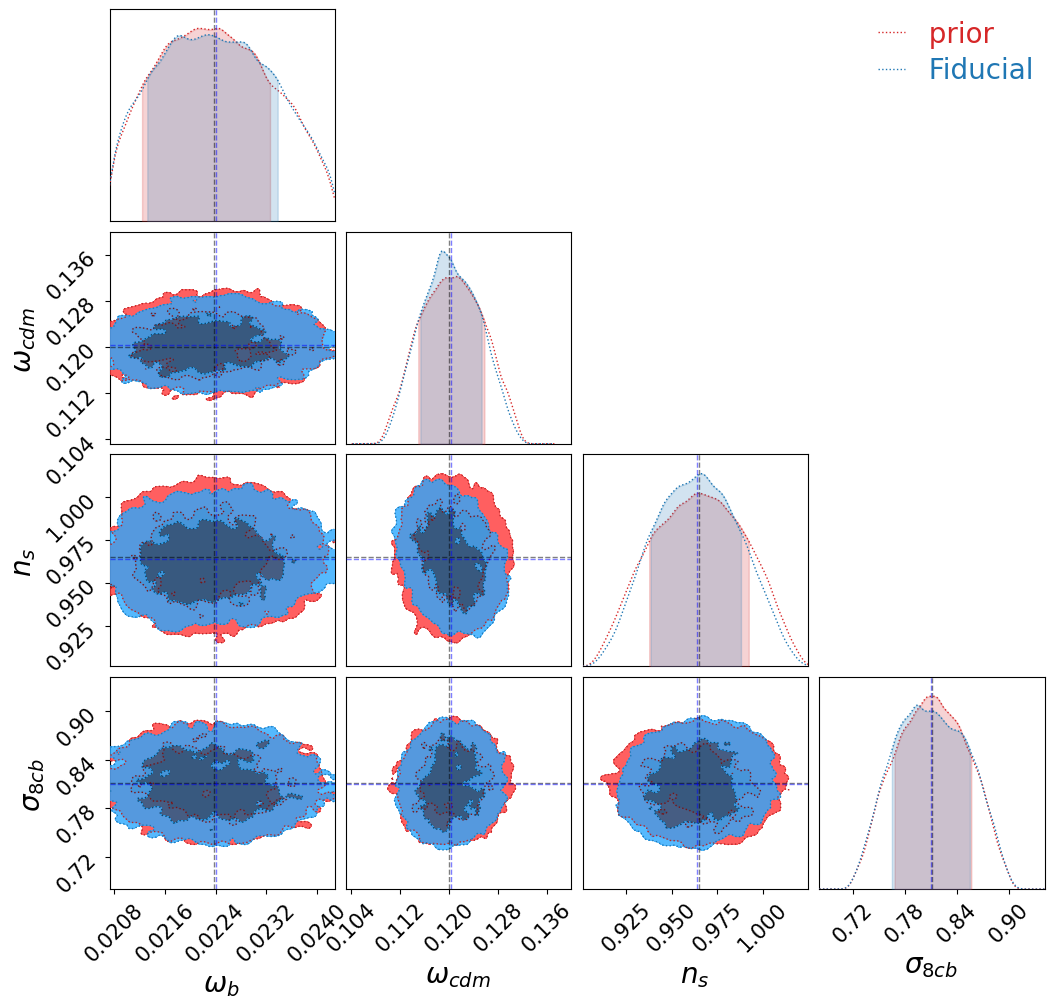

In [94]:
cc = plot_cosmo_contours(samples_set_e_uniform, fiducial=data_params, label = 'prior', color = 'tab:red', 
                              truth_color='black',
                              #point_names_subset = ['omega_cdm', 'n_s', 'sigma8_cb',],
                         point_names_subset = ['omega_b', 'omega_cdm', 'n_s', 'sigma8_cb',], make_plot=False
                             )
fig, cc = plot_cosmo_contours(samples_set_e_c000, fiducial=best_fit, label = 'Fiducial', color = 'tab:blue', 
                              truth_color='blue',
                                                       point_names_subset = ['omega_b', 'omega_cdm', 'n_s', 'sigma8_cb',],
                             chain_consumer = cc,
                             )


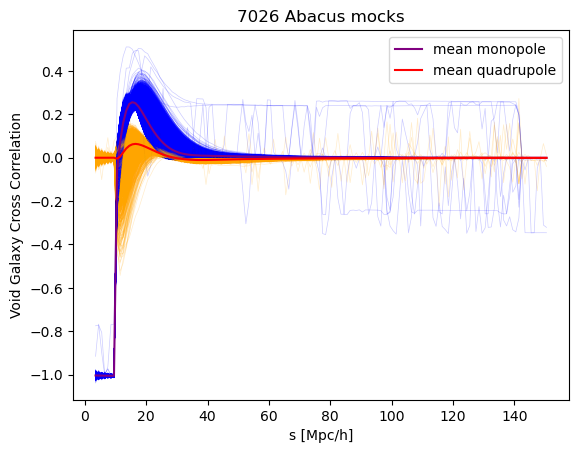

In [129]:
for i in range(vgcc_values.shape[0]):
    plt.plot(((np.array(sedges)[1:]+np.array(sedges)[:-1])/2)[2:150],
        vgcc_values[i][:(len(vgcc_values[0]))//2],
            linewidth=.5, alpha = .2, color='blue')
    plt.plot(((np.array(sedges)[1:]+np.array(sedges)[:-1])/2)[2:150],
        vgcc_values[i][(len(vgcc_values[0]))//2:],
            linewidth=.5, alpha = 0.2, color='orange')
plt.plot(((np.array(sedges)[1:]+np.array(sedges)[:-1])/2)[2:150],
        np.mean(vgcc_values,axis=0)[:(len(vgcc_values[0]))//2],
            color='purple', label = 'mean monopole')
plt.plot(((np.array(sedges)[1:]+np.array(sedges)[:-1])/2)[2:150],
        np.mean(vgcc_values,axis=0)[(len(vgcc_values[0]))//2:],
            color='red',  label = 'mean quadrupole')
plt.xlabel('s [Mpc/h]')
plt.ylabel('Void Galaxy Cross Correlation')
plt.legend()
plt.title(f'{vgcc_values.shape[0]} Abacus mocks');

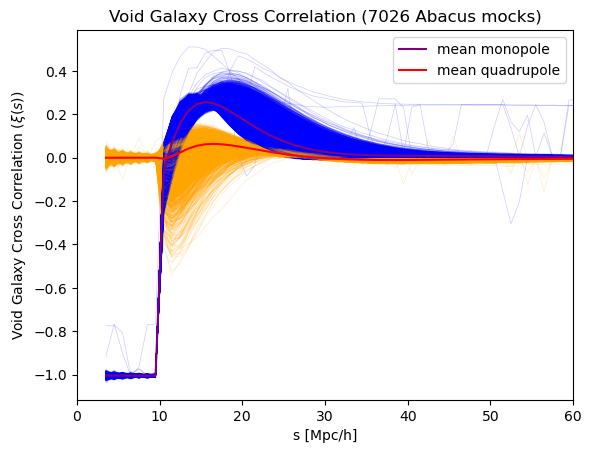

In [131]:
for i in range(vgcc_values.shape[0]):
    plt.plot(((np.array(sedges)[1:]+np.array(sedges)[:-1])/2)[2:150],
        vgcc_values[i][:(len(vgcc_values[0]))//2],
            linewidth=.5, alpha = .2, color='blue')
    plt.plot(((np.array(sedges)[1:]+np.array(sedges)[:-1])/2)[2:150],
        vgcc_values[i][(len(vgcc_values[0]))//2:],
            linewidth=.5, alpha = 0.2, color='orange')
plt.plot(((np.array(sedges)[1:]+np.array(sedges)[:-1])/2)[2:150],
        np.mean(vgcc_values,axis=0)[:(len(vgcc_values[0]))//2],
            color='purple', label = 'mean monopole')
plt.plot(((np.array(sedges)[1:]+np.array(sedges)[:-1])/2)[2:150],
        np.mean(vgcc_values,axis=0)[(len(vgcc_values[0]))//2:],
            color='red',  label = 'mean quadrupole')
plt.xlabel('s [Mpc/h]')
plt.ylabel('Void Galaxy Cross Correlation ($\\xi (s)$)')
plt.legend()
plt.xlim(0,60)
plt.title(f'Void Galaxy Cross Correlation ({vgcc_values.shape[0]} Abacus mocks)');

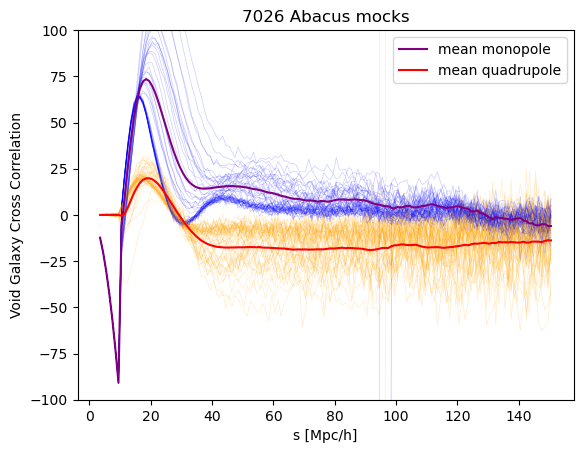

In [50]:
s_val = ((np.array(sedges)[1:]+np.array(sedges)[:-1])/2)[2:150]
for i in range(50):#(vgcc_values.shape[0]):
    plt.plot(s_val,
        s_val*s_val*vgcc_values[i][:(len(vgcc_values[0]))//2],
            linewidth=.5, alpha = .2, color='blue')
    plt.plot(s_val,
        s_val*s_val*vgcc_values[i][(len(vgcc_values[0]))//2:],
            linewidth=.5, alpha = 0.2, color='orange')
plt.plot(s_val,
        s_val*s_val*np.mean(vgcc_values,axis=0)[:(len(vgcc_values[0]))//2],
            color='purple', label = 'mean monopole')
plt.plot(s_val,
        s_val*s_val*np.mean(vgcc_values,axis=0)[(len(vgcc_values[0]))//2:],
            color='red',  label = 'mean quadrupole')
plt.xlabel('s [Mpc/h]')
plt.ylabel('Void Galaxy Cross Correlation')
plt.ylim(-100,100)
plt.legend()
plt.title(f'{vgcc_values.shape[0]} Abacus mocks');